# **Labelling + Embedding on LFW**
Author: Aditya Khadkikar

> Run the cells in "Getting Started with LFW" only if you do not have the locally saved images of LFW.

In [1]:
! pip install deepface --quiet
import cv2, polars as pl, matplotlib.pyplot as plt
import os, pickle, glob, numpy as np
from PIL import Image
from deepface import DeepFace
from datasets import load_dataset
from sklearn.manifold import TSNE

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.1/133.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.9 MB/s eta 0:00:00
26-01-08 23:50:59 - Directory /root/.deepface has been created
26-01-08 23:50:59 - Directory /root/.deepface/weights has been created


## **Getting Started with LFW**

https://huggingface.co/datasets/bitmind/lfw

This is how the collection of individuals with >= 20 images of themselves (GT20 subset), is filtered from the original LFW dataset loaded from HuggingFace. This will be needed for all subsequent parts of the analysis.

> Save the collection as a zip file `intra-sim.zip`, for not having to do the dataset filtering many times (as it is time-consuming).

Roughly 158 people have 10 images of themselves.

~ 96 people have 15 images of themselves.

~ 62 people have $\geq$ 20 images of themselves.

In [ ]:
# https://huggingface.co/datasets/bitmind/lfw
# If using the LFW dataset

from datasets import load_dataset
ds = load_dataset("bitmind/lfw")

lfw = ds["train"]

In [ ]:
# A way to find which people have at least N number of photos
N = 20
lfw_min20_photos = lfw.filter(lambda x: f'00{N}' in x['filename'] if N < 100 else f'0{N}' in x['filename'])

person_images = {}
people = [i.split('0')[0] for i in lfw_min20_photos['filename']]  # just extract the names

os.mkdir("intra-sim")

for i, person in enumerate(people):
  print("Progress:", (i/len(people)))
  person_images[person] = lfw.filter(lambda x: person in x["filename"])[:20] # find all matching images with that name, and cap to 20 for uniformity
  os.mkdir(f'intra-sim/{person}')
  for i, image in enumerate(person_images[person]['image']):
    image.save(f'intra-sim/{person}/{i+1}.png')

# later, save as a zip file.

## **Embeddings and Representation**

https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html

In [ ]:
! unzip intra-sim.zip

In [4]:
model = "Facenet512"
lfw_embedded = {}

for person in glob.glob(f'intra-sim/*'):
  images = glob.glob(f'{person}/*.png')
  for i, image in enumerate(images):
    try:
      print(image)
      lfw_embedded[f'intra-sim/{person}/{i+1}.png'] = DeepFace.represent(image, model_name=model) # VGGFace if model_name not specified
    except ValueError:
      print(f"error with image >>", image) # here, detection phase was unsuccessful
      lfw_embedded[image] = None

26-01-08 23:55:58 - 🔗 facenet512_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet512_weights.h5 to /root/.deepface/weights/facenet512_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet512_weights.h5
To: /root/.deepface/weights/facenet512_weights.h5
100%|██████████| 95.0M/95.0M [00:00<00:00, 159MB/s]


error with image >> intra-sim/Atal_Bihari_Vajpayee_/15.png
error with image >> intra-sim/Guillermo_Coria_/11.png
error with image >> intra-sim/Mahmoud_Abbas_/4.png
error with image >> intra-sim/Michael_Bloomberg_/13.png
error with image >> intra-sim/Hamid_Karzai_/4.png
error with image >> intra-sim/Kofi_Annan_/12.png
error with image >> intra-sim/Lindsay_Davenport_/10.png
error with image >> intra-sim/Arnold_Schwarzenegger_/14.png
error with image >> intra-sim/Jiang_Zemin_/15.png
error with image >> intra-sim/Jiang_Zemin_/14.png
error with image >> intra-sim/Ariel_Sharon_/8.png
error with image >> intra-sim/Serena_Williams_/3.png
error with image >> intra-sim/Serena_Williams_/18.png
error with image >> intra-sim/Serena_Williams_/2.png
error with image >> intra-sim/Serena_Williams_/19.png
error with image >> intra-sim/Serena_Williams_/5.png
error with image >> intra-sim/Igor_Ivanov_/4.png
error with image >> intra-sim/Pete_Sampras_/18.png
error with image >> intra-sim/Silvio_Berlusconi_

In [ ]:
# if multiple faces, find face where face confidence largest
[lfw_embedded['intra-sim/intra-sim/Gray_Davis_/1.png'][i]['embedding'] for i in range(len(lfw_embedded['intra-sim/intra-sim/Gray_Davis_/1.png']))]

In [54]:
# GROUP BY PERSON, and EMBEDDINGS OF ALL IMAGES IDENTIFYING TO THAT PERSON
X = {}
for person in glob.glob(f'intra-sim/*'):
  X[person.replace('intra-sim/', '')] = {}
  for image_path in lfw_embedded.keys():
    if lfw_embedded[image_path] is not None and person in image_path:
      X[person.replace('intra-sim/', '')][f'{image_path.replace("intra-sim/intra-sim/", "intra-sim/")}'] = {}
      X[person.replace('intra-sim/', '')][f'{image_path.replace("intra-sim/intra-sim/", "intra-sim/")}']['embedding'] = np.array(lfw_embedded[image_path][np.argmax([lfw_embedded[image_path][i]['face_confidence'] for i in range(len(lfw_embedded[image_path]))])]['embedding'])

In [57]:
X['Alejandro_Toledo_']['intra-sim/Alejandro_Toledo_/1.png']['embedding'].shape

(512,)

In [108]:
pure_embeddings = []

for person in X.keys():
  for impath in X[person].keys():
    pure_embeddings.append(X[person][impath]['embedding'])

Number of embedded imgs -- 20
intra-sim/Gray_Davis_/1.png
intra-sim/Gray_Davis_/2.png
intra-sim/Gray_Davis_/3.png
intra-sim/Gray_Davis_/4.png
intra-sim/Gray_Davis_/5.png
intra-sim/Gray_Davis_/6.png
intra-sim/Gray_Davis_/7.png
intra-sim/Gray_Davis_/8.png
intra-sim/Gray_Davis_/9.png
intra-sim/Gray_Davis_/10.png
intra-sim/Gray_Davis_/11.png
intra-sim/Gray_Davis_/12.png
intra-sim/Gray_Davis_/13.png
intra-sim/Gray_Davis_/14.png
intra-sim/Gray_Davis_/15.png
intra-sim/Gray_Davis_/16.png
intra-sim/Gray_Davis_/17.png
intra-sim/Gray_Davis_/18.png
intra-sim/Gray_Davis_/19.png
intra-sim/Gray_Davis_/20.png


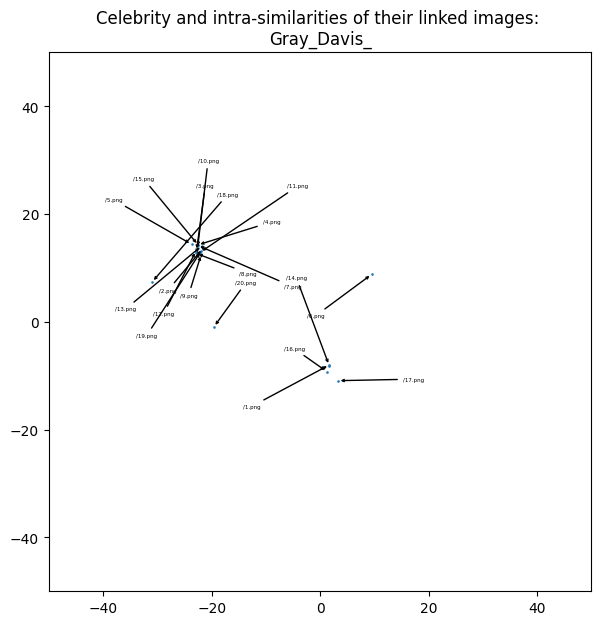

Number of embedded imgs -- 20
intra-sim/Paul_Bremer_/1.png
intra-sim/Paul_Bremer_/2.png
intra-sim/Paul_Bremer_/3.png
intra-sim/Paul_Bremer_/4.png
intra-sim/Paul_Bremer_/5.png
intra-sim/Paul_Bremer_/6.png
intra-sim/Paul_Bremer_/7.png
intra-sim/Paul_Bremer_/8.png
intra-sim/Paul_Bremer_/9.png
intra-sim/Paul_Bremer_/10.png
intra-sim/Paul_Bremer_/11.png
intra-sim/Paul_Bremer_/12.png
intra-sim/Paul_Bremer_/13.png
intra-sim/Paul_Bremer_/14.png
intra-sim/Paul_Bremer_/15.png
intra-sim/Paul_Bremer_/16.png
intra-sim/Paul_Bremer_/17.png
intra-sim/Paul_Bremer_/18.png
intra-sim/Paul_Bremer_/19.png
intra-sim/Paul_Bremer_/20.png


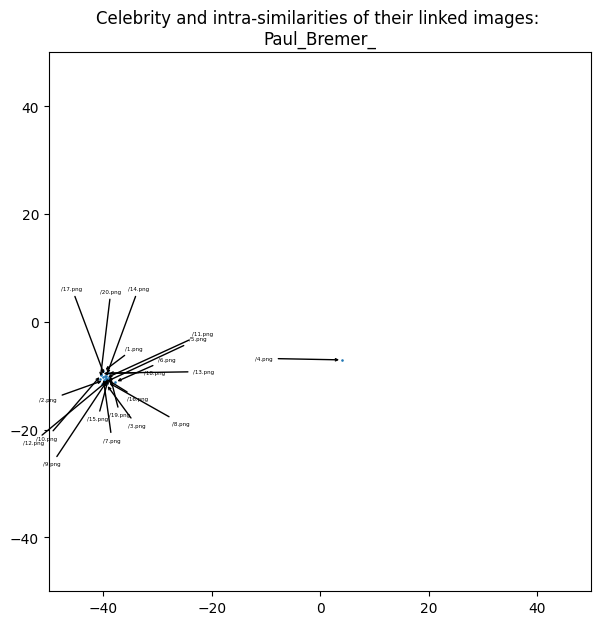

Number of embedded imgs -- 20
intra-sim/Junichiro_Koizumi_/1.png
intra-sim/Junichiro_Koizumi_/2.png
intra-sim/Junichiro_Koizumi_/3.png
intra-sim/Junichiro_Koizumi_/4.png
intra-sim/Junichiro_Koizumi_/5.png
intra-sim/Junichiro_Koizumi_/6.png
intra-sim/Junichiro_Koizumi_/7.png
intra-sim/Junichiro_Koizumi_/8.png
intra-sim/Junichiro_Koizumi_/9.png
intra-sim/Junichiro_Koizumi_/10.png
intra-sim/Junichiro_Koizumi_/11.png
intra-sim/Junichiro_Koizumi_/12.png
intra-sim/Junichiro_Koizumi_/13.png
intra-sim/Junichiro_Koizumi_/14.png
intra-sim/Junichiro_Koizumi_/15.png
intra-sim/Junichiro_Koizumi_/16.png
intra-sim/Junichiro_Koizumi_/17.png
intra-sim/Junichiro_Koizumi_/18.png
intra-sim/Junichiro_Koizumi_/19.png
intra-sim/Junichiro_Koizumi_/20.png


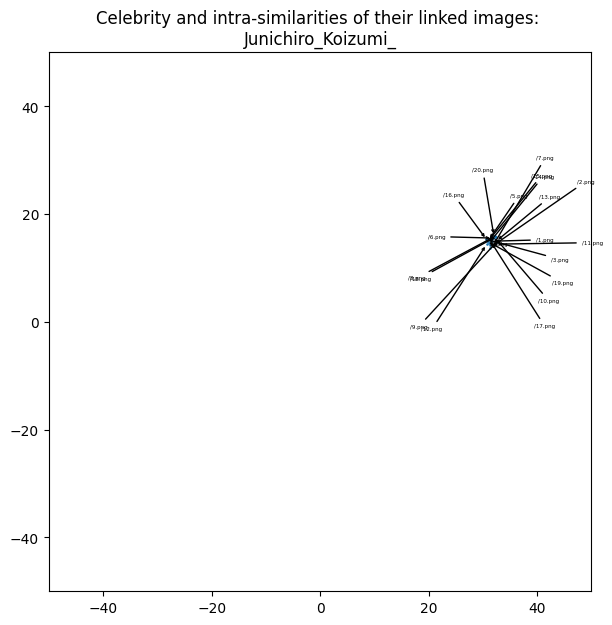

Number of embedded imgs -- 20
intra-sim/Tom_Daschle_/1.png
intra-sim/Tom_Daschle_/2.png
intra-sim/Tom_Daschle_/3.png
intra-sim/Tom_Daschle_/4.png
intra-sim/Tom_Daschle_/5.png
intra-sim/Tom_Daschle_/6.png
intra-sim/Tom_Daschle_/7.png
intra-sim/Tom_Daschle_/8.png
intra-sim/Tom_Daschle_/9.png
intra-sim/Tom_Daschle_/10.png
intra-sim/Tom_Daschle_/11.png
intra-sim/Tom_Daschle_/12.png
intra-sim/Tom_Daschle_/13.png
intra-sim/Tom_Daschle_/14.png
intra-sim/Tom_Daschle_/15.png
intra-sim/Tom_Daschle_/16.png
intra-sim/Tom_Daschle_/17.png
intra-sim/Tom_Daschle_/18.png
intra-sim/Tom_Daschle_/19.png
intra-sim/Tom_Daschle_/20.png


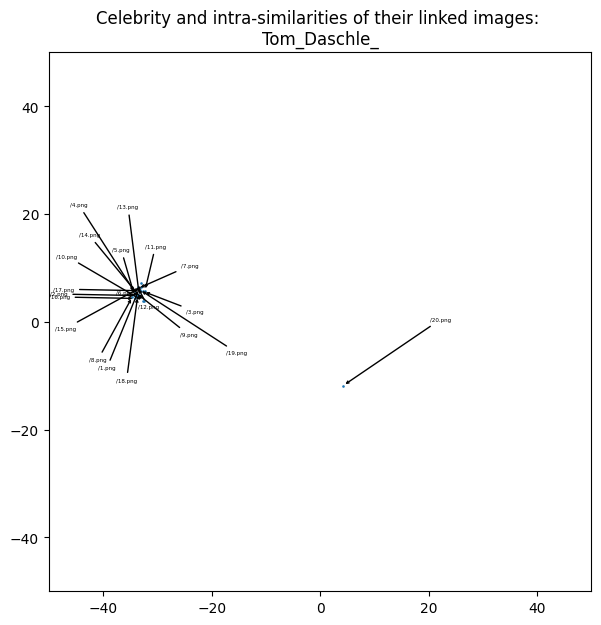

Number of embedded imgs -- 19
intra-sim/Atal_Bihari_Vajpayee_/1.png
intra-sim/Atal_Bihari_Vajpayee_/3.png
intra-sim/Atal_Bihari_Vajpayee_/4.png
intra-sim/Atal_Bihari_Vajpayee_/5.png
intra-sim/Atal_Bihari_Vajpayee_/6.png
intra-sim/Atal_Bihari_Vajpayee_/7.png
intra-sim/Atal_Bihari_Vajpayee_/8.png
intra-sim/Atal_Bihari_Vajpayee_/9.png
intra-sim/Atal_Bihari_Vajpayee_/10.png
intra-sim/Atal_Bihari_Vajpayee_/11.png
intra-sim/Atal_Bihari_Vajpayee_/12.png
intra-sim/Atal_Bihari_Vajpayee_/13.png
intra-sim/Atal_Bihari_Vajpayee_/14.png
intra-sim/Atal_Bihari_Vajpayee_/15.png
intra-sim/Atal_Bihari_Vajpayee_/16.png
intra-sim/Atal_Bihari_Vajpayee_/17.png
intra-sim/Atal_Bihari_Vajpayee_/18.png
intra-sim/Atal_Bihari_Vajpayee_/19.png
intra-sim/Atal_Bihari_Vajpayee_/20.png


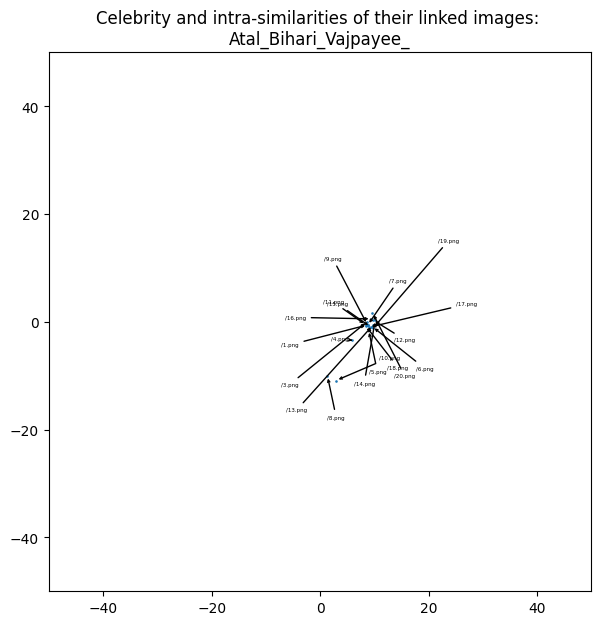

Number of embedded imgs -- 19
intra-sim/Guillermo_Coria_/1.png
intra-sim/Guillermo_Coria_/2.png
intra-sim/Guillermo_Coria_/3.png
intra-sim/Guillermo_Coria_/4.png
intra-sim/Guillermo_Coria_/5.png
intra-sim/Guillermo_Coria_/6.png
intra-sim/Guillermo_Coria_/7.png
intra-sim/Guillermo_Coria_/8.png
intra-sim/Guillermo_Coria_/9.png
intra-sim/Guillermo_Coria_/10.png
intra-sim/Guillermo_Coria_/11.png
intra-sim/Guillermo_Coria_/12.png
intra-sim/Guillermo_Coria_/14.png
intra-sim/Guillermo_Coria_/15.png
intra-sim/Guillermo_Coria_/16.png
intra-sim/Guillermo_Coria_/17.png
intra-sim/Guillermo_Coria_/18.png
intra-sim/Guillermo_Coria_/19.png
intra-sim/Guillermo_Coria_/20.png


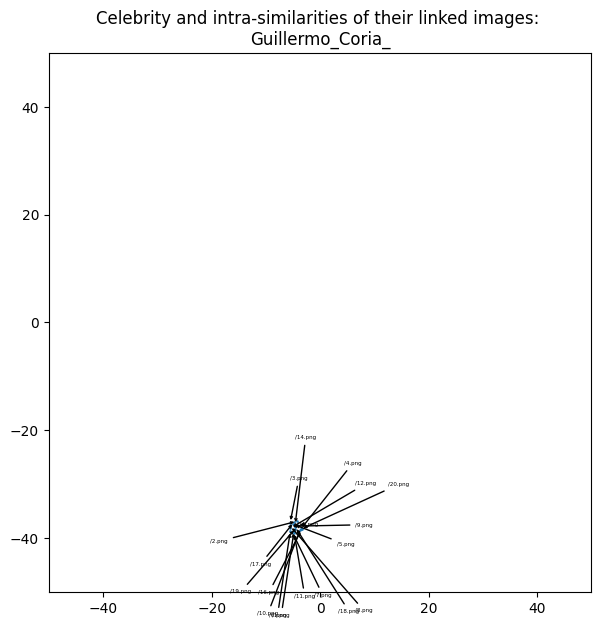

Number of embedded imgs -- 20
intra-sim/John_Negroponte_/1.png
intra-sim/John_Negroponte_/2.png
intra-sim/John_Negroponte_/3.png
intra-sim/John_Negroponte_/4.png
intra-sim/John_Negroponte_/5.png
intra-sim/John_Negroponte_/6.png
intra-sim/John_Negroponte_/7.png
intra-sim/John_Negroponte_/8.png
intra-sim/John_Negroponte_/9.png
intra-sim/John_Negroponte_/10.png
intra-sim/John_Negroponte_/11.png
intra-sim/John_Negroponte_/12.png
intra-sim/John_Negroponte_/13.png
intra-sim/John_Negroponte_/14.png
intra-sim/John_Negroponte_/15.png
intra-sim/John_Negroponte_/16.png
intra-sim/John_Negroponte_/17.png
intra-sim/John_Negroponte_/18.png
intra-sim/John_Negroponte_/19.png
intra-sim/John_Negroponte_/20.png


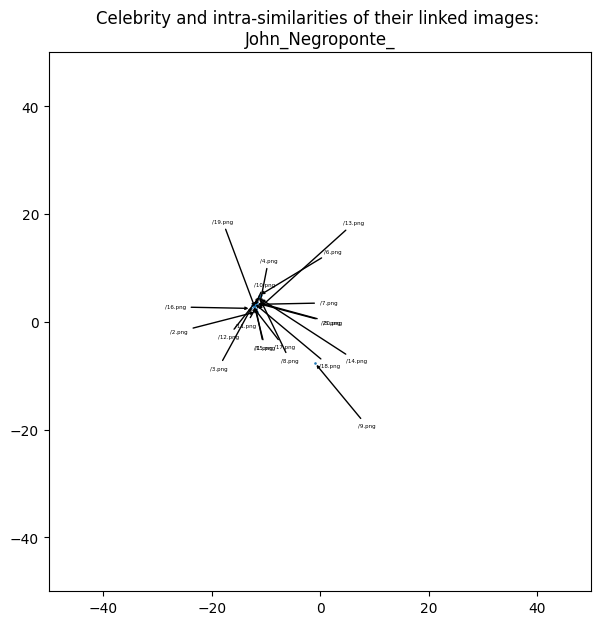

Number of embedded imgs -- 19
intra-sim/Mahmoud_Abbas_/1.png
intra-sim/Mahmoud_Abbas_/2.png
intra-sim/Mahmoud_Abbas_/3.png
intra-sim/Mahmoud_Abbas_/4.png
intra-sim/Mahmoud_Abbas_/5.png
intra-sim/Mahmoud_Abbas_/6.png
intra-sim/Mahmoud_Abbas_/7.png
intra-sim/Mahmoud_Abbas_/8.png
intra-sim/Mahmoud_Abbas_/9.png
intra-sim/Mahmoud_Abbas_/10.png
intra-sim/Mahmoud_Abbas_/11.png
intra-sim/Mahmoud_Abbas_/12.png
intra-sim/Mahmoud_Abbas_/13.png
intra-sim/Mahmoud_Abbas_/14.png
intra-sim/Mahmoud_Abbas_/15.png
intra-sim/Mahmoud_Abbas_/16.png
intra-sim/Mahmoud_Abbas_/17.png
intra-sim/Mahmoud_Abbas_/19.png
intra-sim/Mahmoud_Abbas_/20.png


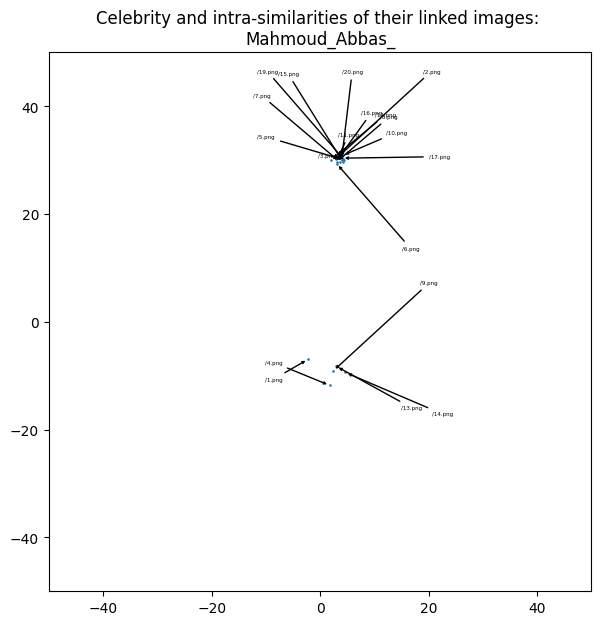

Number of embedded imgs -- 19
intra-sim/Michael_Bloomberg_/1.png
intra-sim/Michael_Bloomberg_/2.png
intra-sim/Michael_Bloomberg_/3.png
intra-sim/Michael_Bloomberg_/5.png
intra-sim/Michael_Bloomberg_/6.png
intra-sim/Michael_Bloomberg_/7.png
intra-sim/Michael_Bloomberg_/8.png
intra-sim/Michael_Bloomberg_/9.png
intra-sim/Michael_Bloomberg_/10.png
intra-sim/Michael_Bloomberg_/11.png
intra-sim/Michael_Bloomberg_/12.png
intra-sim/Michael_Bloomberg_/13.png
intra-sim/Michael_Bloomberg_/14.png
intra-sim/Michael_Bloomberg_/15.png
intra-sim/Michael_Bloomberg_/16.png
intra-sim/Michael_Bloomberg_/17.png
intra-sim/Michael_Bloomberg_/18.png
intra-sim/Michael_Bloomberg_/19.png
intra-sim/Michael_Bloomberg_/20.png


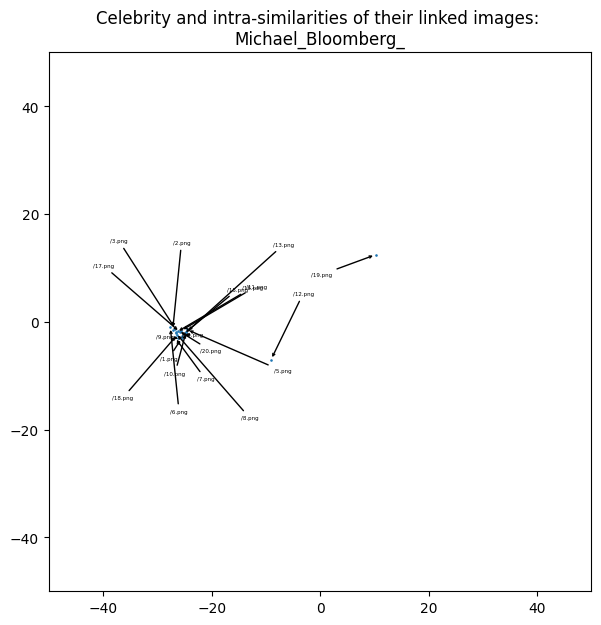

Number of embedded imgs -- 20
intra-sim/Roh_Moo-hyun_/1.png
intra-sim/Roh_Moo-hyun_/2.png
intra-sim/Roh_Moo-hyun_/3.png
intra-sim/Roh_Moo-hyun_/4.png
intra-sim/Roh_Moo-hyun_/5.png
intra-sim/Roh_Moo-hyun_/6.png
intra-sim/Roh_Moo-hyun_/7.png
intra-sim/Roh_Moo-hyun_/8.png
intra-sim/Roh_Moo-hyun_/9.png
intra-sim/Roh_Moo-hyun_/10.png
intra-sim/Roh_Moo-hyun_/11.png
intra-sim/Roh_Moo-hyun_/12.png
intra-sim/Roh_Moo-hyun_/13.png
intra-sim/Roh_Moo-hyun_/14.png
intra-sim/Roh_Moo-hyun_/15.png
intra-sim/Roh_Moo-hyun_/16.png
intra-sim/Roh_Moo-hyun_/17.png
intra-sim/Roh_Moo-hyun_/18.png
intra-sim/Roh_Moo-hyun_/19.png
intra-sim/Roh_Moo-hyun_/20.png


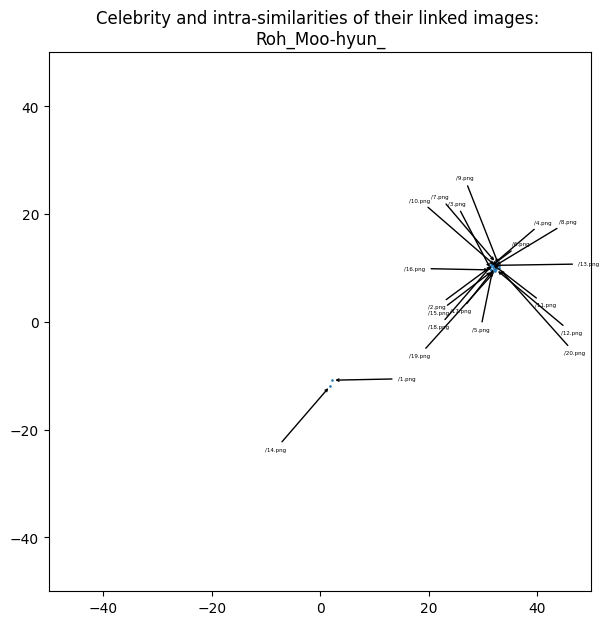

Number of embedded imgs -- 20
intra-sim/David_Beckham_/1.png
intra-sim/David_Beckham_/2.png
intra-sim/David_Beckham_/3.png
intra-sim/David_Beckham_/4.png
intra-sim/David_Beckham_/5.png
intra-sim/David_Beckham_/6.png
intra-sim/David_Beckham_/7.png
intra-sim/David_Beckham_/8.png
intra-sim/David_Beckham_/9.png
intra-sim/David_Beckham_/10.png
intra-sim/David_Beckham_/11.png
intra-sim/David_Beckham_/12.png
intra-sim/David_Beckham_/13.png
intra-sim/David_Beckham_/14.png
intra-sim/David_Beckham_/15.png
intra-sim/David_Beckham_/16.png
intra-sim/David_Beckham_/17.png
intra-sim/David_Beckham_/18.png
intra-sim/David_Beckham_/19.png
intra-sim/David_Beckham_/20.png


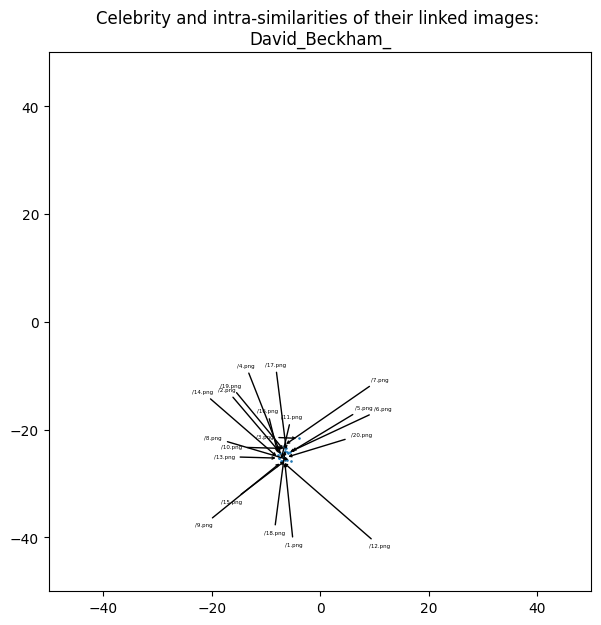

Number of embedded imgs -- 20
intra-sim/George_Robertson_/1.png
intra-sim/George_Robertson_/2.png
intra-sim/George_Robertson_/3.png
intra-sim/George_Robertson_/4.png
intra-sim/George_Robertson_/5.png
intra-sim/George_Robertson_/6.png
intra-sim/George_Robertson_/7.png
intra-sim/George_Robertson_/8.png
intra-sim/George_Robertson_/9.png
intra-sim/George_Robertson_/10.png
intra-sim/George_Robertson_/11.png
intra-sim/George_Robertson_/12.png
intra-sim/George_Robertson_/13.png
intra-sim/George_Robertson_/14.png
intra-sim/George_Robertson_/15.png
intra-sim/George_Robertson_/16.png
intra-sim/George_Robertson_/17.png
intra-sim/George_Robertson_/18.png
intra-sim/George_Robertson_/19.png
intra-sim/George_Robertson_/20.png


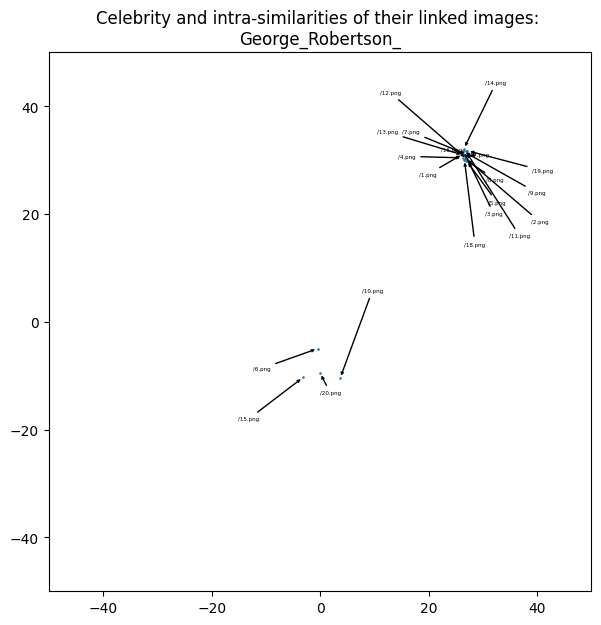

Number of embedded imgs -- 19
intra-sim/Hamid_Karzai_/1.png
intra-sim/Hamid_Karzai_/2.png
intra-sim/Hamid_Karzai_/3.png
intra-sim/Hamid_Karzai_/4.png
intra-sim/Hamid_Karzai_/5.png
intra-sim/Hamid_Karzai_/6.png
intra-sim/Hamid_Karzai_/7.png
intra-sim/Hamid_Karzai_/8.png
intra-sim/Hamid_Karzai_/9.png
intra-sim/Hamid_Karzai_/10.png
intra-sim/Hamid_Karzai_/11.png
intra-sim/Hamid_Karzai_/12.png
intra-sim/Hamid_Karzai_/13.png
intra-sim/Hamid_Karzai_/14.png
intra-sim/Hamid_Karzai_/15.png
intra-sim/Hamid_Karzai_/16.png
intra-sim/Hamid_Karzai_/17.png
intra-sim/Hamid_Karzai_/19.png
intra-sim/Hamid_Karzai_/20.png


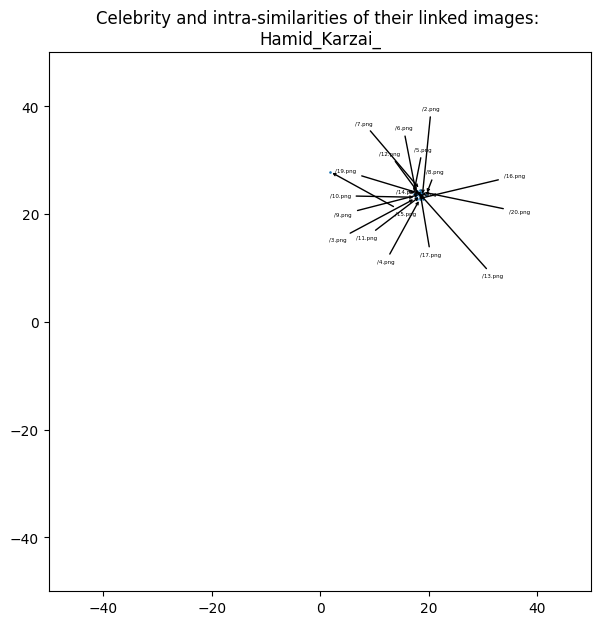

Number of embedded imgs -- 19
intra-sim/Kofi_Annan_/1.png
intra-sim/Kofi_Annan_/2.png
intra-sim/Kofi_Annan_/3.png
intra-sim/Kofi_Annan_/4.png
intra-sim/Kofi_Annan_/5.png
intra-sim/Kofi_Annan_/6.png
intra-sim/Kofi_Annan_/7.png
intra-sim/Kofi_Annan_/8.png
intra-sim/Kofi_Annan_/9.png
intra-sim/Kofi_Annan_/10.png
intra-sim/Kofi_Annan_/11.png
intra-sim/Kofi_Annan_/12.png
intra-sim/Kofi_Annan_/13.png
intra-sim/Kofi_Annan_/15.png
intra-sim/Kofi_Annan_/16.png
intra-sim/Kofi_Annan_/17.png
intra-sim/Kofi_Annan_/18.png
intra-sim/Kofi_Annan_/19.png
intra-sim/Kofi_Annan_/20.png


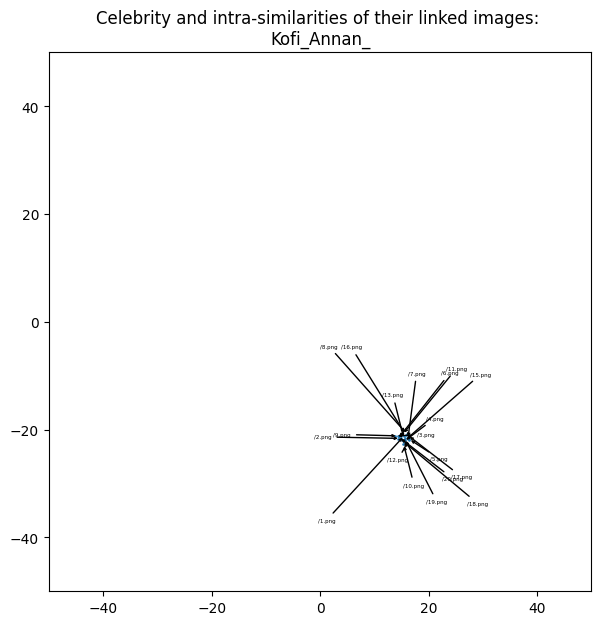

Number of embedded imgs -- 20
intra-sim/Jennifer_Aniston_/1.png
intra-sim/Jennifer_Aniston_/2.png
intra-sim/Jennifer_Aniston_/3.png
intra-sim/Jennifer_Aniston_/4.png
intra-sim/Jennifer_Aniston_/5.png
intra-sim/Jennifer_Aniston_/6.png
intra-sim/Jennifer_Aniston_/7.png
intra-sim/Jennifer_Aniston_/8.png
intra-sim/Jennifer_Aniston_/9.png
intra-sim/Jennifer_Aniston_/10.png
intra-sim/Jennifer_Aniston_/11.png
intra-sim/Jennifer_Aniston_/12.png
intra-sim/Jennifer_Aniston_/13.png
intra-sim/Jennifer_Aniston_/14.png
intra-sim/Jennifer_Aniston_/15.png
intra-sim/Jennifer_Aniston_/16.png
intra-sim/Jennifer_Aniston_/17.png
intra-sim/Jennifer_Aniston_/18.png
intra-sim/Jennifer_Aniston_/19.png
intra-sim/Jennifer_Aniston_/20.png


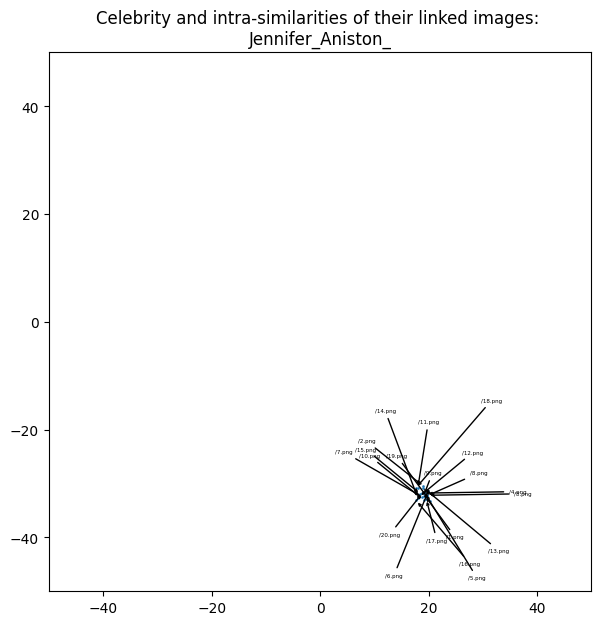

Number of embedded imgs -- 20
intra-sim/Colin_Powell_/1.png
intra-sim/Colin_Powell_/2.png
intra-sim/Colin_Powell_/3.png
intra-sim/Colin_Powell_/4.png
intra-sim/Colin_Powell_/5.png
intra-sim/Colin_Powell_/6.png
intra-sim/Colin_Powell_/7.png
intra-sim/Colin_Powell_/8.png
intra-sim/Colin_Powell_/9.png
intra-sim/Colin_Powell_/10.png
intra-sim/Colin_Powell_/11.png
intra-sim/Colin_Powell_/12.png
intra-sim/Colin_Powell_/13.png
intra-sim/Colin_Powell_/14.png
intra-sim/Colin_Powell_/15.png
intra-sim/Colin_Powell_/16.png
intra-sim/Colin_Powell_/17.png
intra-sim/Colin_Powell_/18.png
intra-sim/Colin_Powell_/19.png
intra-sim/Colin_Powell_/20.png


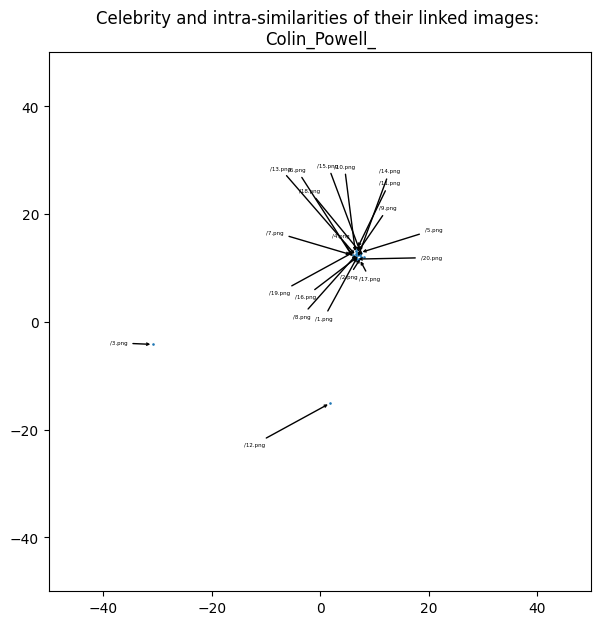

Number of embedded imgs -- 19
intra-sim/Lindsay_Davenport_/1.png
intra-sim/Lindsay_Davenport_/2.png
intra-sim/Lindsay_Davenport_/3.png
intra-sim/Lindsay_Davenport_/4.png
intra-sim/Lindsay_Davenport_/5.png
intra-sim/Lindsay_Davenport_/6.png
intra-sim/Lindsay_Davenport_/7.png
intra-sim/Lindsay_Davenport_/8.png
intra-sim/Lindsay_Davenport_/9.png
intra-sim/Lindsay_Davenport_/11.png
intra-sim/Lindsay_Davenport_/12.png
intra-sim/Lindsay_Davenport_/13.png
intra-sim/Lindsay_Davenport_/14.png
intra-sim/Lindsay_Davenport_/15.png
intra-sim/Lindsay_Davenport_/16.png
intra-sim/Lindsay_Davenport_/17.png
intra-sim/Lindsay_Davenport_/18.png
intra-sim/Lindsay_Davenport_/19.png
intra-sim/Lindsay_Davenport_/20.png


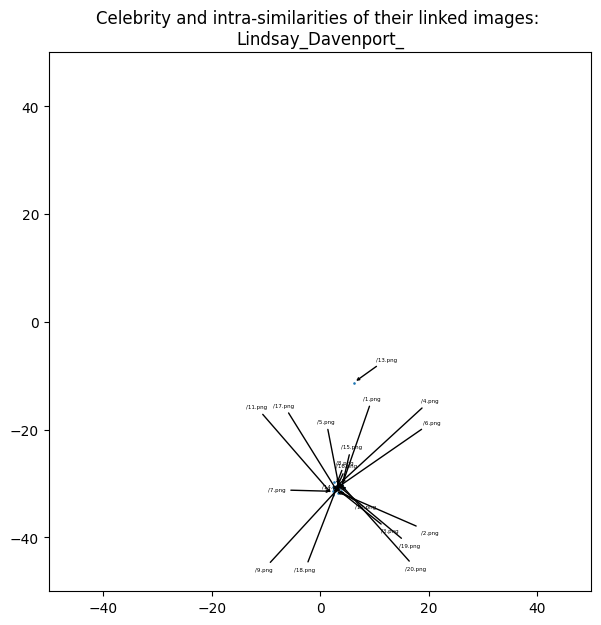

Number of embedded imgs -- 20
intra-sim/Amelie_Mauresmo_/1.png
intra-sim/Amelie_Mauresmo_/2.png
intra-sim/Amelie_Mauresmo_/3.png
intra-sim/Amelie_Mauresmo_/4.png
intra-sim/Amelie_Mauresmo_/5.png
intra-sim/Amelie_Mauresmo_/6.png
intra-sim/Amelie_Mauresmo_/7.png
intra-sim/Amelie_Mauresmo_/8.png
intra-sim/Amelie_Mauresmo_/9.png
intra-sim/Amelie_Mauresmo_/10.png
intra-sim/Amelie_Mauresmo_/11.png
intra-sim/Amelie_Mauresmo_/12.png
intra-sim/Amelie_Mauresmo_/13.png
intra-sim/Amelie_Mauresmo_/14.png
intra-sim/Amelie_Mauresmo_/15.png
intra-sim/Amelie_Mauresmo_/16.png
intra-sim/Amelie_Mauresmo_/17.png
intra-sim/Amelie_Mauresmo_/18.png
intra-sim/Amelie_Mauresmo_/19.png
intra-sim/Amelie_Mauresmo_/20.png


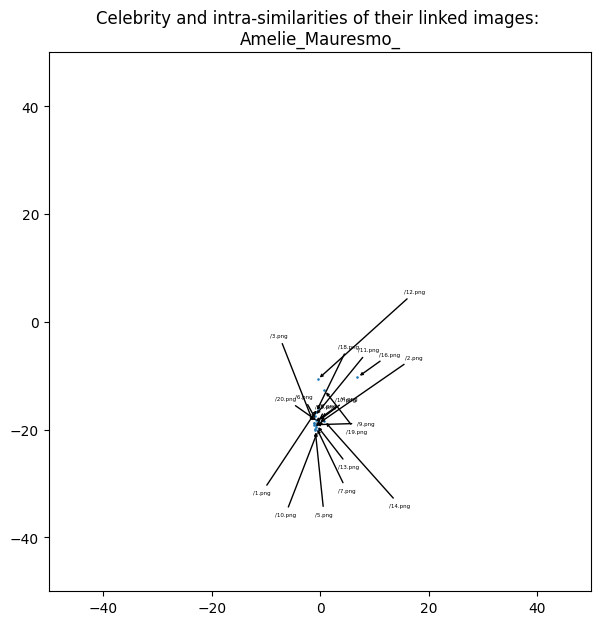

Number of embedded imgs -- 19
intra-sim/Arnold_Schwarzenegger_/1.png
intra-sim/Arnold_Schwarzenegger_/2.png
intra-sim/Arnold_Schwarzenegger_/3.png
intra-sim/Arnold_Schwarzenegger_/4.png
intra-sim/Arnold_Schwarzenegger_/5.png
intra-sim/Arnold_Schwarzenegger_/6.png
intra-sim/Arnold_Schwarzenegger_/7.png
intra-sim/Arnold_Schwarzenegger_/8.png
intra-sim/Arnold_Schwarzenegger_/9.png
intra-sim/Arnold_Schwarzenegger_/10.png
intra-sim/Arnold_Schwarzenegger_/11.png
intra-sim/Arnold_Schwarzenegger_/13.png
intra-sim/Arnold_Schwarzenegger_/14.png
intra-sim/Arnold_Schwarzenegger_/15.png
intra-sim/Arnold_Schwarzenegger_/16.png
intra-sim/Arnold_Schwarzenegger_/17.png
intra-sim/Arnold_Schwarzenegger_/18.png
intra-sim/Arnold_Schwarzenegger_/19.png
intra-sim/Arnold_Schwarzenegger_/20.png


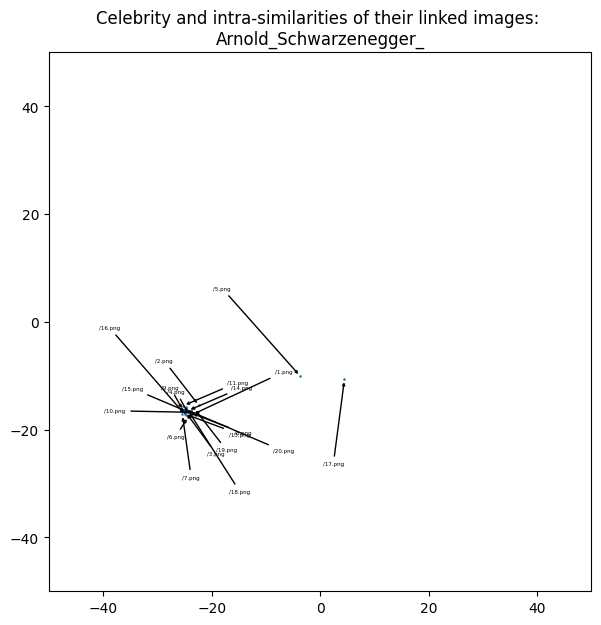

Number of embedded imgs -- 18
intra-sim/Jiang_Zemin_/1.png
intra-sim/Jiang_Zemin_/3.png
intra-sim/Jiang_Zemin_/4.png
intra-sim/Jiang_Zemin_/5.png
intra-sim/Jiang_Zemin_/6.png
intra-sim/Jiang_Zemin_/7.png
intra-sim/Jiang_Zemin_/8.png
intra-sim/Jiang_Zemin_/9.png
intra-sim/Jiang_Zemin_/10.png
intra-sim/Jiang_Zemin_/11.png
intra-sim/Jiang_Zemin_/13.png
intra-sim/Jiang_Zemin_/14.png
intra-sim/Jiang_Zemin_/15.png
intra-sim/Jiang_Zemin_/16.png
intra-sim/Jiang_Zemin_/17.png
intra-sim/Jiang_Zemin_/18.png
intra-sim/Jiang_Zemin_/19.png
intra-sim/Jiang_Zemin_/20.png


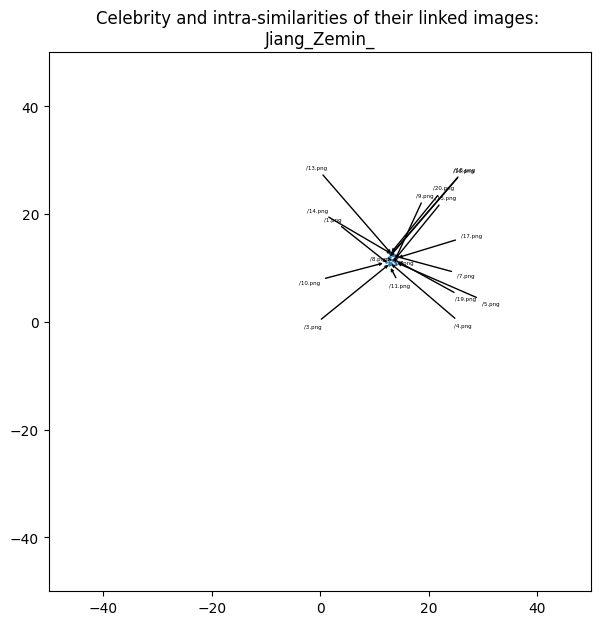

Number of embedded imgs -- 20
intra-sim/Andre_Agassi_/1.png
intra-sim/Andre_Agassi_/2.png
intra-sim/Andre_Agassi_/3.png
intra-sim/Andre_Agassi_/4.png
intra-sim/Andre_Agassi_/5.png
intra-sim/Andre_Agassi_/6.png
intra-sim/Andre_Agassi_/7.png
intra-sim/Andre_Agassi_/8.png
intra-sim/Andre_Agassi_/9.png
intra-sim/Andre_Agassi_/10.png
intra-sim/Andre_Agassi_/11.png
intra-sim/Andre_Agassi_/12.png
intra-sim/Andre_Agassi_/13.png
intra-sim/Andre_Agassi_/14.png
intra-sim/Andre_Agassi_/15.png
intra-sim/Andre_Agassi_/16.png
intra-sim/Andre_Agassi_/17.png
intra-sim/Andre_Agassi_/18.png
intra-sim/Andre_Agassi_/19.png
intra-sim/Andre_Agassi_/20.png


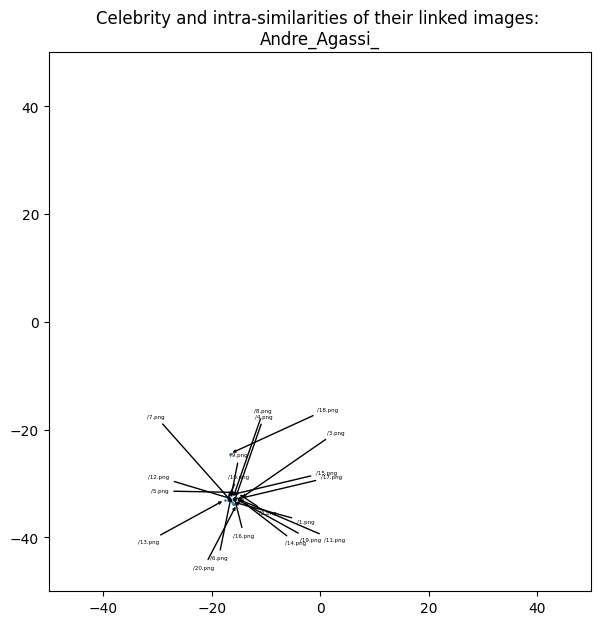

Number of embedded imgs -- 20
intra-sim/Recep_Tayyip_Erdogan_/1.png
intra-sim/Recep_Tayyip_Erdogan_/2.png
intra-sim/Recep_Tayyip_Erdogan_/3.png
intra-sim/Recep_Tayyip_Erdogan_/4.png
intra-sim/Recep_Tayyip_Erdogan_/5.png
intra-sim/Recep_Tayyip_Erdogan_/6.png
intra-sim/Recep_Tayyip_Erdogan_/7.png
intra-sim/Recep_Tayyip_Erdogan_/8.png
intra-sim/Recep_Tayyip_Erdogan_/9.png
intra-sim/Recep_Tayyip_Erdogan_/10.png
intra-sim/Recep_Tayyip_Erdogan_/11.png
intra-sim/Recep_Tayyip_Erdogan_/12.png
intra-sim/Recep_Tayyip_Erdogan_/13.png
intra-sim/Recep_Tayyip_Erdogan_/14.png
intra-sim/Recep_Tayyip_Erdogan_/15.png
intra-sim/Recep_Tayyip_Erdogan_/16.png
intra-sim/Recep_Tayyip_Erdogan_/17.png
intra-sim/Recep_Tayyip_Erdogan_/18.png
intra-sim/Recep_Tayyip_Erdogan_/19.png
intra-sim/Recep_Tayyip_Erdogan_/20.png


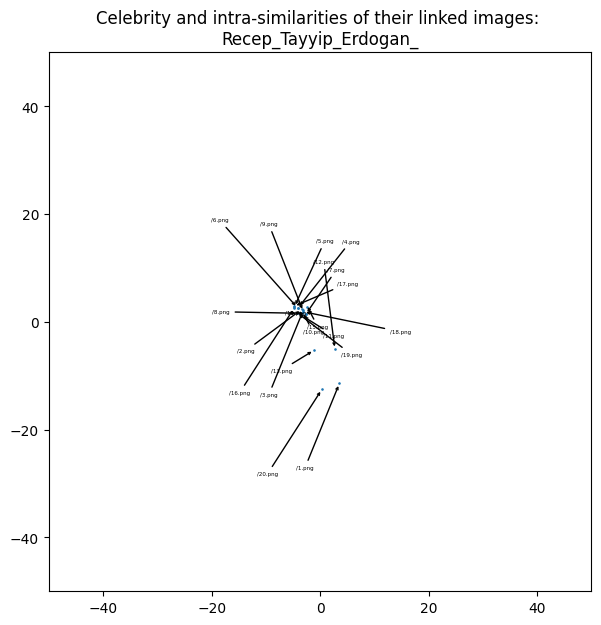

Number of embedded imgs -- 20
intra-sim/Tony_Blair_/1.png
intra-sim/Tony_Blair_/2.png
intra-sim/Tony_Blair_/3.png
intra-sim/Tony_Blair_/4.png
intra-sim/Tony_Blair_/5.png
intra-sim/Tony_Blair_/6.png
intra-sim/Tony_Blair_/7.png
intra-sim/Tony_Blair_/8.png
intra-sim/Tony_Blair_/9.png
intra-sim/Tony_Blair_/10.png
intra-sim/Tony_Blair_/11.png
intra-sim/Tony_Blair_/12.png
intra-sim/Tony_Blair_/13.png
intra-sim/Tony_Blair_/14.png
intra-sim/Tony_Blair_/15.png
intra-sim/Tony_Blair_/16.png
intra-sim/Tony_Blair_/17.png
intra-sim/Tony_Blair_/18.png
intra-sim/Tony_Blair_/19.png
intra-sim/Tony_Blair_/20.png


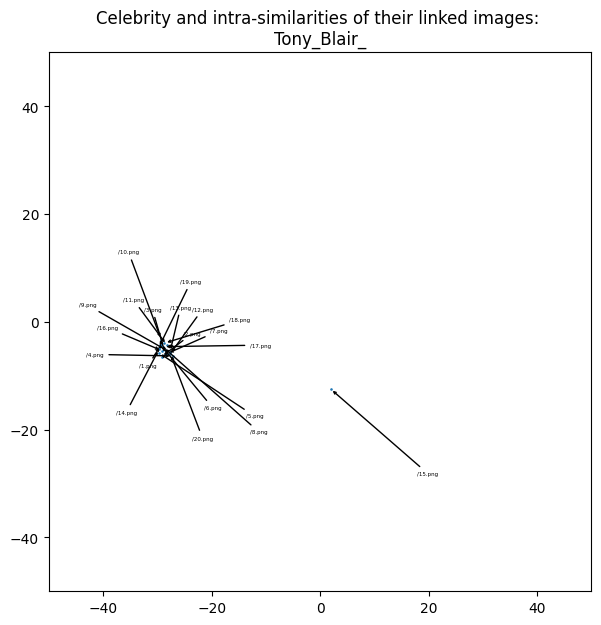

Number of embedded imgs -- 20
intra-sim/Lleyton_Hewitt_/1.png
intra-sim/Lleyton_Hewitt_/2.png
intra-sim/Lleyton_Hewitt_/3.png
intra-sim/Lleyton_Hewitt_/4.png
intra-sim/Lleyton_Hewitt_/5.png
intra-sim/Lleyton_Hewitt_/6.png
intra-sim/Lleyton_Hewitt_/7.png
intra-sim/Lleyton_Hewitt_/8.png
intra-sim/Lleyton_Hewitt_/9.png
intra-sim/Lleyton_Hewitt_/10.png
intra-sim/Lleyton_Hewitt_/11.png
intra-sim/Lleyton_Hewitt_/12.png
intra-sim/Lleyton_Hewitt_/13.png
intra-sim/Lleyton_Hewitt_/14.png
intra-sim/Lleyton_Hewitt_/15.png
intra-sim/Lleyton_Hewitt_/16.png
intra-sim/Lleyton_Hewitt_/17.png
intra-sim/Lleyton_Hewitt_/18.png
intra-sim/Lleyton_Hewitt_/19.png
intra-sim/Lleyton_Hewitt_/20.png


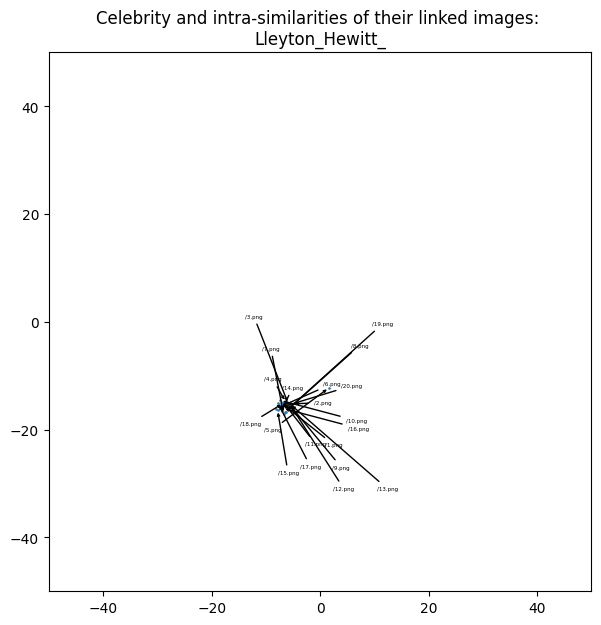

Number of embedded imgs -- 20
intra-sim/Rudolph_Giuliani_/1.png
intra-sim/Rudolph_Giuliani_/2.png
intra-sim/Rudolph_Giuliani_/3.png
intra-sim/Rudolph_Giuliani_/4.png
intra-sim/Rudolph_Giuliani_/5.png
intra-sim/Rudolph_Giuliani_/6.png
intra-sim/Rudolph_Giuliani_/7.png
intra-sim/Rudolph_Giuliani_/8.png
intra-sim/Rudolph_Giuliani_/9.png
intra-sim/Rudolph_Giuliani_/10.png
intra-sim/Rudolph_Giuliani_/11.png
intra-sim/Rudolph_Giuliani_/12.png
intra-sim/Rudolph_Giuliani_/13.png
intra-sim/Rudolph_Giuliani_/14.png
intra-sim/Rudolph_Giuliani_/15.png
intra-sim/Rudolph_Giuliani_/16.png
intra-sim/Rudolph_Giuliani_/17.png
intra-sim/Rudolph_Giuliani_/18.png
intra-sim/Rudolph_Giuliani_/19.png
intra-sim/Rudolph_Giuliani_/20.png


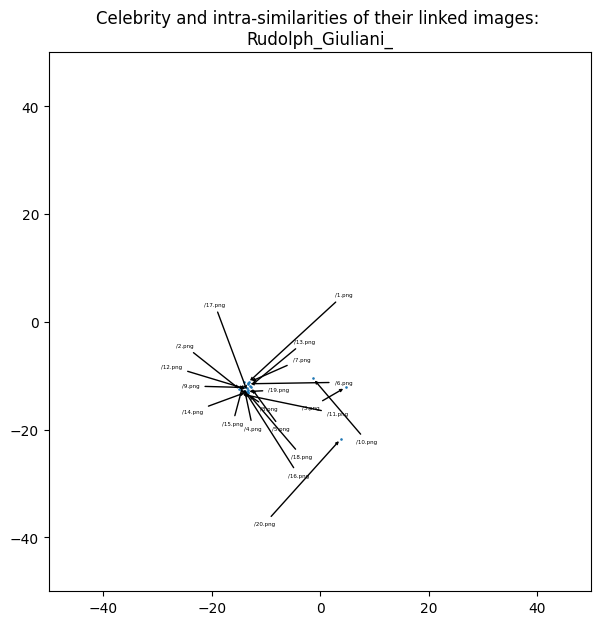

Number of embedded imgs -- 19
intra-sim/Ariel_Sharon_/1.png
intra-sim/Ariel_Sharon_/2.png
intra-sim/Ariel_Sharon_/3.png
intra-sim/Ariel_Sharon_/4.png
intra-sim/Ariel_Sharon_/5.png
intra-sim/Ariel_Sharon_/6.png
intra-sim/Ariel_Sharon_/7.png
intra-sim/Ariel_Sharon_/8.png
intra-sim/Ariel_Sharon_/9.png
intra-sim/Ariel_Sharon_/10.png
intra-sim/Ariel_Sharon_/11.png
intra-sim/Ariel_Sharon_/12.png
intra-sim/Ariel_Sharon_/13.png
intra-sim/Ariel_Sharon_/14.png
intra-sim/Ariel_Sharon_/15.png
intra-sim/Ariel_Sharon_/16.png
intra-sim/Ariel_Sharon_/18.png
intra-sim/Ariel_Sharon_/19.png
intra-sim/Ariel_Sharon_/20.png


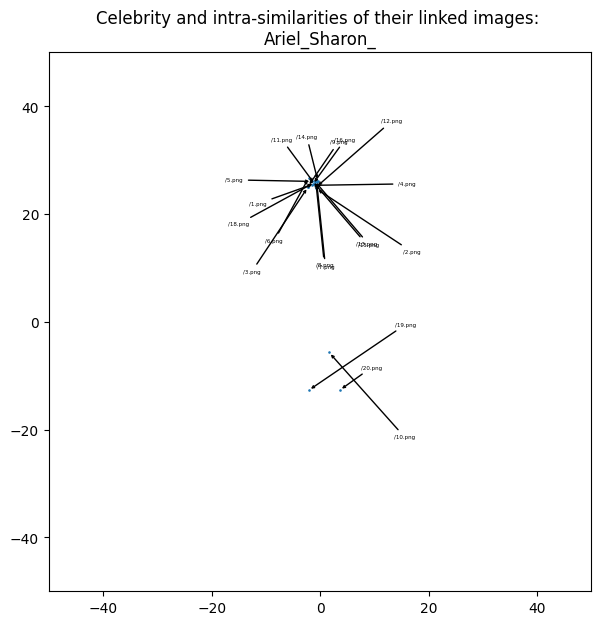

Number of embedded imgs -- 20
intra-sim/Carlos_Menem_/1.png
intra-sim/Carlos_Menem_/2.png
intra-sim/Carlos_Menem_/3.png
intra-sim/Carlos_Menem_/4.png
intra-sim/Carlos_Menem_/5.png
intra-sim/Carlos_Menem_/6.png
intra-sim/Carlos_Menem_/7.png
intra-sim/Carlos_Menem_/8.png
intra-sim/Carlos_Menem_/9.png
intra-sim/Carlos_Menem_/10.png
intra-sim/Carlos_Menem_/11.png
intra-sim/Carlos_Menem_/12.png
intra-sim/Carlos_Menem_/13.png
intra-sim/Carlos_Menem_/14.png
intra-sim/Carlos_Menem_/15.png
intra-sim/Carlos_Menem_/16.png
intra-sim/Carlos_Menem_/17.png
intra-sim/Carlos_Menem_/18.png
intra-sim/Carlos_Menem_/19.png
intra-sim/Carlos_Menem_/20.png


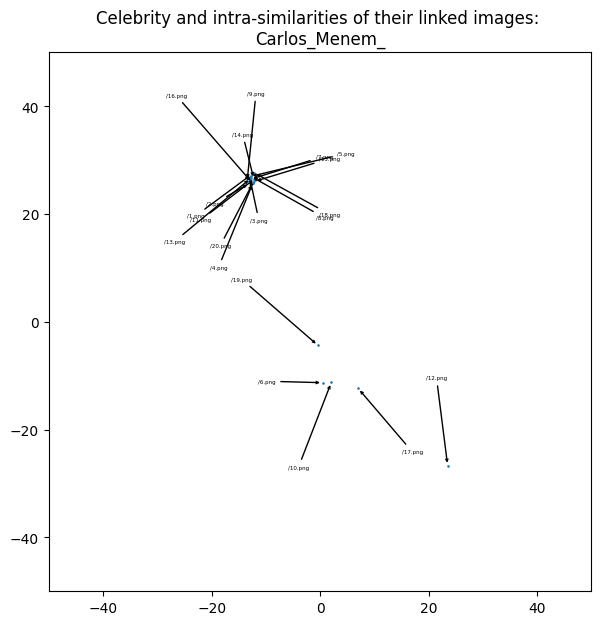

Number of embedded imgs -- 15
intra-sim/Serena_Williams_/2.png
intra-sim/Serena_Williams_/3.png
intra-sim/Serena_Williams_/4.png
intra-sim/Serena_Williams_/5.png
intra-sim/Serena_Williams_/6.png
intra-sim/Serena_Williams_/7.png
intra-sim/Serena_Williams_/9.png
intra-sim/Serena_Williams_/10.png
intra-sim/Serena_Williams_/11.png
intra-sim/Serena_Williams_/12.png
intra-sim/Serena_Williams_/13.png
intra-sim/Serena_Williams_/14.png
intra-sim/Serena_Williams_/17.png
intra-sim/Serena_Williams_/18.png
intra-sim/Serena_Williams_/20.png


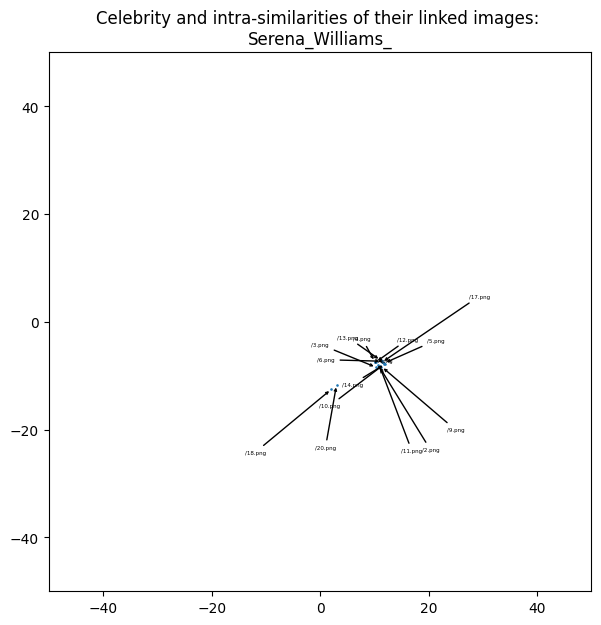

Number of embedded imgs -- 20
intra-sim/Alvaro_Uribe_/1.png
intra-sim/Alvaro_Uribe_/2.png
intra-sim/Alvaro_Uribe_/3.png
intra-sim/Alvaro_Uribe_/4.png
intra-sim/Alvaro_Uribe_/5.png
intra-sim/Alvaro_Uribe_/6.png
intra-sim/Alvaro_Uribe_/7.png
intra-sim/Alvaro_Uribe_/8.png
intra-sim/Alvaro_Uribe_/9.png
intra-sim/Alvaro_Uribe_/10.png
intra-sim/Alvaro_Uribe_/11.png
intra-sim/Alvaro_Uribe_/12.png
intra-sim/Alvaro_Uribe_/13.png
intra-sim/Alvaro_Uribe_/14.png
intra-sim/Alvaro_Uribe_/15.png
intra-sim/Alvaro_Uribe_/16.png
intra-sim/Alvaro_Uribe_/17.png
intra-sim/Alvaro_Uribe_/18.png
intra-sim/Alvaro_Uribe_/19.png
intra-sim/Alvaro_Uribe_/20.png


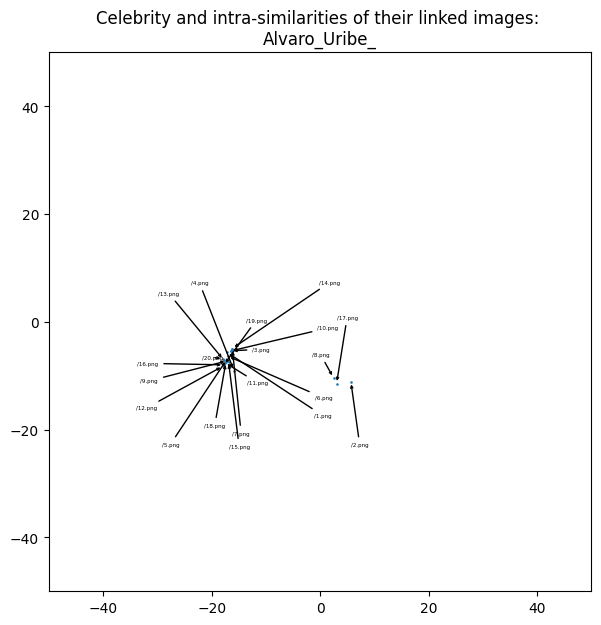

Number of embedded imgs -- 20
intra-sim/Tom_Ridge_/1.png
intra-sim/Tom_Ridge_/2.png
intra-sim/Tom_Ridge_/3.png
intra-sim/Tom_Ridge_/4.png
intra-sim/Tom_Ridge_/5.png
intra-sim/Tom_Ridge_/6.png
intra-sim/Tom_Ridge_/7.png
intra-sim/Tom_Ridge_/8.png
intra-sim/Tom_Ridge_/9.png
intra-sim/Tom_Ridge_/10.png
intra-sim/Tom_Ridge_/11.png
intra-sim/Tom_Ridge_/12.png
intra-sim/Tom_Ridge_/13.png
intra-sim/Tom_Ridge_/14.png
intra-sim/Tom_Ridge_/15.png
intra-sim/Tom_Ridge_/16.png
intra-sim/Tom_Ridge_/17.png
intra-sim/Tom_Ridge_/18.png
intra-sim/Tom_Ridge_/19.png
intra-sim/Tom_Ridge_/20.png


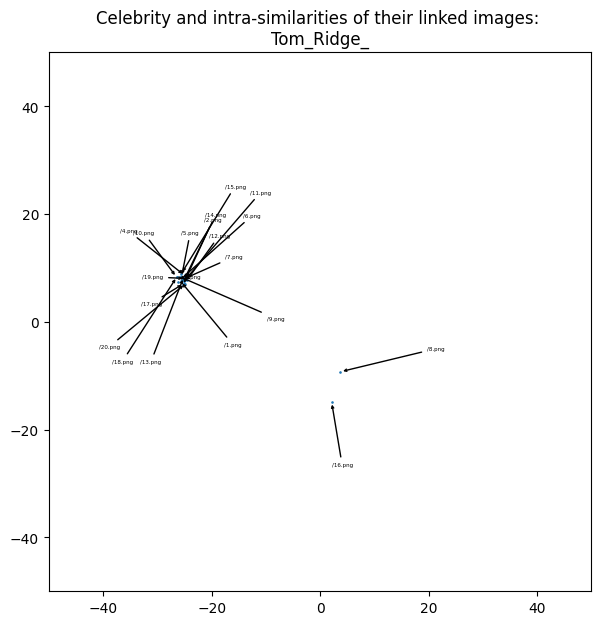

Number of embedded imgs -- 20
intra-sim/Jose_Maria_Aznar_/1.png
intra-sim/Jose_Maria_Aznar_/2.png
intra-sim/Jose_Maria_Aznar_/3.png
intra-sim/Jose_Maria_Aznar_/4.png
intra-sim/Jose_Maria_Aznar_/5.png
intra-sim/Jose_Maria_Aznar_/6.png
intra-sim/Jose_Maria_Aznar_/7.png
intra-sim/Jose_Maria_Aznar_/8.png
intra-sim/Jose_Maria_Aznar_/9.png
intra-sim/Jose_Maria_Aznar_/10.png
intra-sim/Jose_Maria_Aznar_/11.png
intra-sim/Jose_Maria_Aznar_/12.png
intra-sim/Jose_Maria_Aznar_/13.png
intra-sim/Jose_Maria_Aznar_/14.png
intra-sim/Jose_Maria_Aznar_/15.png
intra-sim/Jose_Maria_Aznar_/16.png
intra-sim/Jose_Maria_Aznar_/17.png
intra-sim/Jose_Maria_Aznar_/18.png
intra-sim/Jose_Maria_Aznar_/19.png
intra-sim/Jose_Maria_Aznar_/20.png


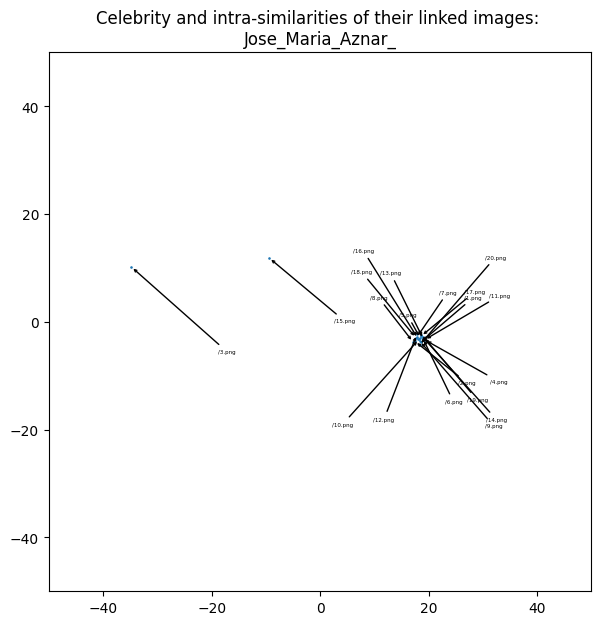

Number of embedded imgs -- 20
intra-sim/Jennifer_Lopez_/1.png
intra-sim/Jennifer_Lopez_/2.png
intra-sim/Jennifer_Lopez_/3.png
intra-sim/Jennifer_Lopez_/4.png
intra-sim/Jennifer_Lopez_/5.png
intra-sim/Jennifer_Lopez_/6.png
intra-sim/Jennifer_Lopez_/7.png
intra-sim/Jennifer_Lopez_/8.png
intra-sim/Jennifer_Lopez_/9.png
intra-sim/Jennifer_Lopez_/10.png
intra-sim/Jennifer_Lopez_/11.png
intra-sim/Jennifer_Lopez_/12.png
intra-sim/Jennifer_Lopez_/13.png
intra-sim/Jennifer_Lopez_/14.png
intra-sim/Jennifer_Lopez_/15.png
intra-sim/Jennifer_Lopez_/16.png
intra-sim/Jennifer_Lopez_/17.png
intra-sim/Jennifer_Lopez_/18.png
intra-sim/Jennifer_Lopez_/19.png
intra-sim/Jennifer_Lopez_/20.png


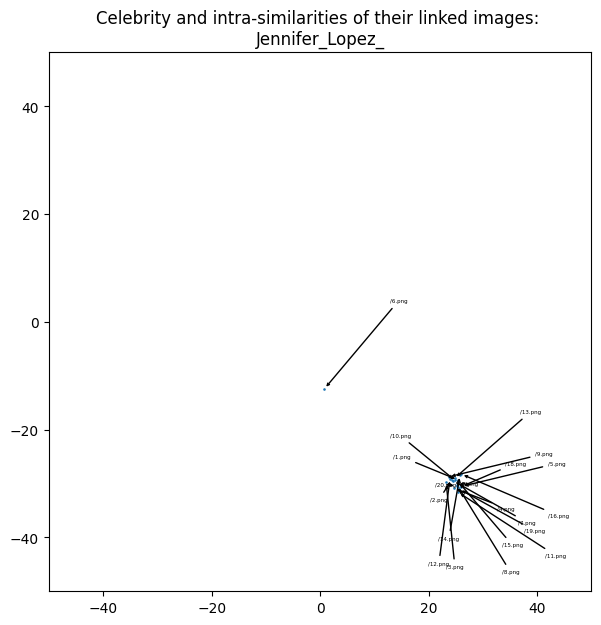

Number of embedded imgs -- 20
intra-sim/Jean_Chretien_/1.png
intra-sim/Jean_Chretien_/2.png
intra-sim/Jean_Chretien_/3.png
intra-sim/Jean_Chretien_/4.png
intra-sim/Jean_Chretien_/5.png
intra-sim/Jean_Chretien_/6.png
intra-sim/Jean_Chretien_/7.png
intra-sim/Jean_Chretien_/8.png
intra-sim/Jean_Chretien_/9.png
intra-sim/Jean_Chretien_/10.png
intra-sim/Jean_Chretien_/11.png
intra-sim/Jean_Chretien_/12.png
intra-sim/Jean_Chretien_/13.png
intra-sim/Jean_Chretien_/14.png
intra-sim/Jean_Chretien_/15.png
intra-sim/Jean_Chretien_/16.png
intra-sim/Jean_Chretien_/17.png
intra-sim/Jean_Chretien_/18.png
intra-sim/Jean_Chretien_/19.png
intra-sim/Jean_Chretien_/20.png


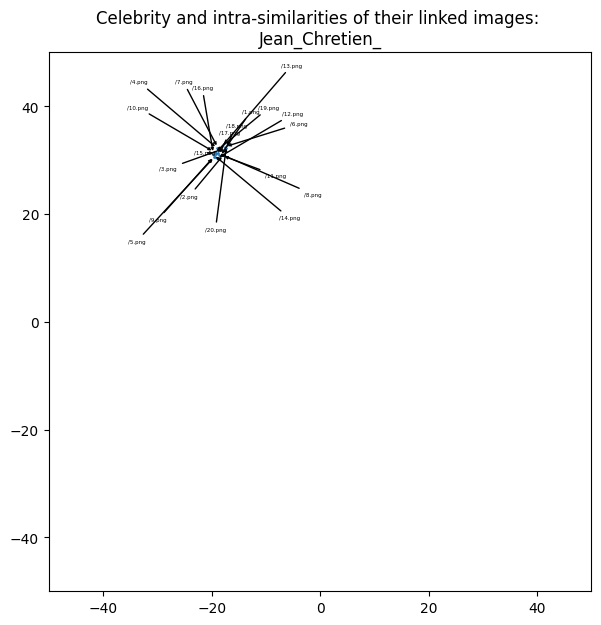

Number of embedded imgs -- 19
intra-sim/Igor_Ivanov_/1.png
intra-sim/Igor_Ivanov_/2.png
intra-sim/Igor_Ivanov_/3.png
intra-sim/Igor_Ivanov_/4.png
intra-sim/Igor_Ivanov_/5.png
intra-sim/Igor_Ivanov_/6.png
intra-sim/Igor_Ivanov_/7.png
intra-sim/Igor_Ivanov_/8.png
intra-sim/Igor_Ivanov_/9.png
intra-sim/Igor_Ivanov_/10.png
intra-sim/Igor_Ivanov_/11.png
intra-sim/Igor_Ivanov_/12.png
intra-sim/Igor_Ivanov_/13.png
intra-sim/Igor_Ivanov_/14.png
intra-sim/Igor_Ivanov_/15.png
intra-sim/Igor_Ivanov_/16.png
intra-sim/Igor_Ivanov_/17.png
intra-sim/Igor_Ivanov_/19.png
intra-sim/Igor_Ivanov_/20.png


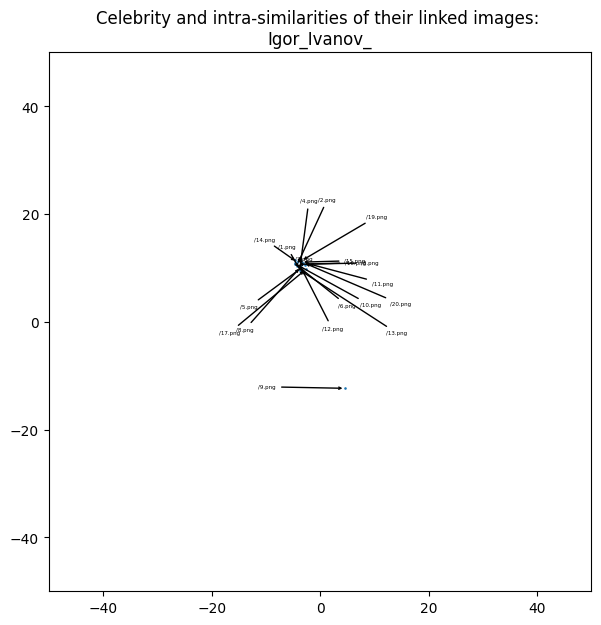

Number of embedded imgs -- 19
intra-sim/Pete_Sampras_/1.png
intra-sim/Pete_Sampras_/2.png
intra-sim/Pete_Sampras_/3.png
intra-sim/Pete_Sampras_/4.png
intra-sim/Pete_Sampras_/5.png
intra-sim/Pete_Sampras_/6.png
intra-sim/Pete_Sampras_/7.png
intra-sim/Pete_Sampras_/9.png
intra-sim/Pete_Sampras_/10.png
intra-sim/Pete_Sampras_/11.png
intra-sim/Pete_Sampras_/12.png
intra-sim/Pete_Sampras_/13.png
intra-sim/Pete_Sampras_/14.png
intra-sim/Pete_Sampras_/15.png
intra-sim/Pete_Sampras_/16.png
intra-sim/Pete_Sampras_/17.png
intra-sim/Pete_Sampras_/18.png
intra-sim/Pete_Sampras_/19.png
intra-sim/Pete_Sampras_/20.png


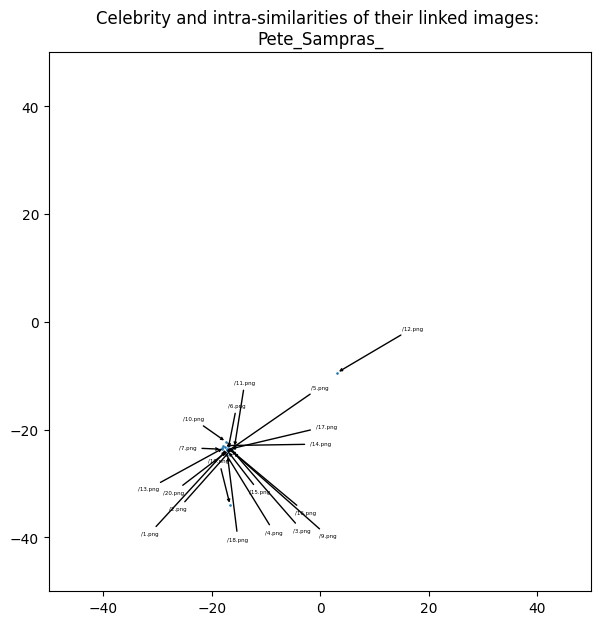

Number of embedded imgs -- 19
intra-sim/Silvio_Berlusconi_/1.png
intra-sim/Silvio_Berlusconi_/2.png
intra-sim/Silvio_Berlusconi_/3.png
intra-sim/Silvio_Berlusconi_/4.png
intra-sim/Silvio_Berlusconi_/5.png
intra-sim/Silvio_Berlusconi_/6.png
intra-sim/Silvio_Berlusconi_/7.png
intra-sim/Silvio_Berlusconi_/8.png
intra-sim/Silvio_Berlusconi_/9.png
intra-sim/Silvio_Berlusconi_/10.png
intra-sim/Silvio_Berlusconi_/11.png
intra-sim/Silvio_Berlusconi_/12.png
intra-sim/Silvio_Berlusconi_/13.png
intra-sim/Silvio_Berlusconi_/14.png
intra-sim/Silvio_Berlusconi_/15.png
intra-sim/Silvio_Berlusconi_/16.png
intra-sim/Silvio_Berlusconi_/18.png
intra-sim/Silvio_Berlusconi_/19.png
intra-sim/Silvio_Berlusconi_/20.png


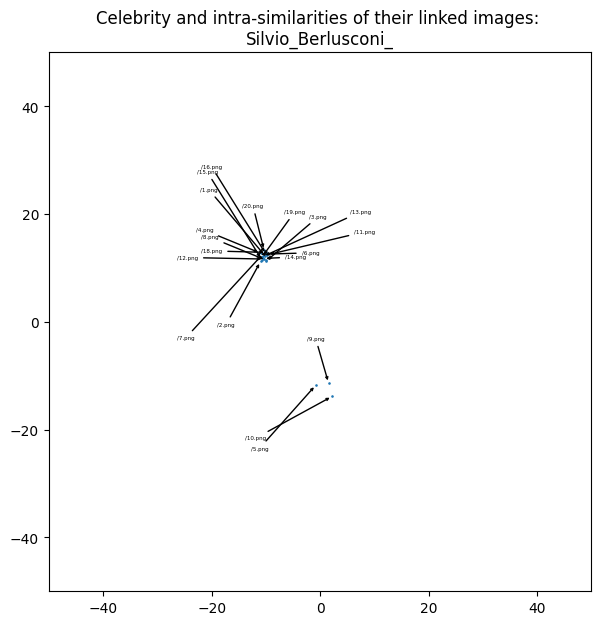

Number of embedded imgs -- 20
intra-sim/Naomi_Watts_/1.png
intra-sim/Naomi_Watts_/2.png
intra-sim/Naomi_Watts_/3.png
intra-sim/Naomi_Watts_/4.png
intra-sim/Naomi_Watts_/5.png
intra-sim/Naomi_Watts_/6.png
intra-sim/Naomi_Watts_/7.png
intra-sim/Naomi_Watts_/8.png
intra-sim/Naomi_Watts_/9.png
intra-sim/Naomi_Watts_/10.png
intra-sim/Naomi_Watts_/11.png
intra-sim/Naomi_Watts_/12.png
intra-sim/Naomi_Watts_/13.png
intra-sim/Naomi_Watts_/14.png
intra-sim/Naomi_Watts_/15.png
intra-sim/Naomi_Watts_/16.png
intra-sim/Naomi_Watts_/17.png
intra-sim/Naomi_Watts_/18.png
intra-sim/Naomi_Watts_/19.png
intra-sim/Naomi_Watts_/20.png


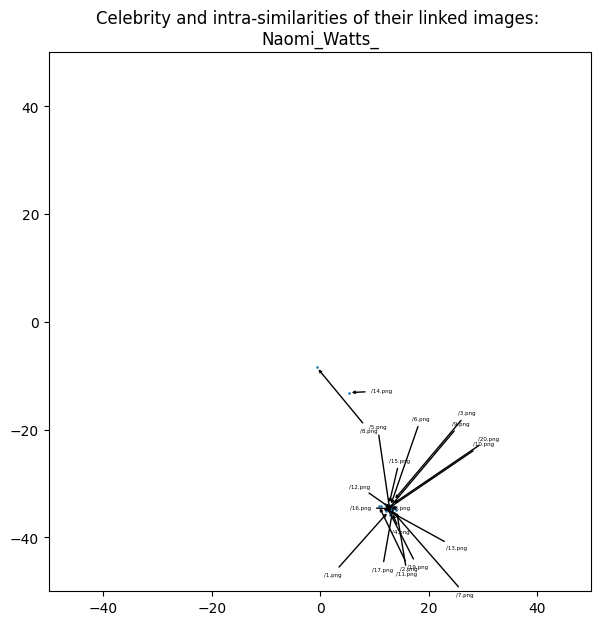

Number of embedded imgs -- 20
intra-sim/Bill_Clinton_/1.png
intra-sim/Bill_Clinton_/2.png
intra-sim/Bill_Clinton_/3.png
intra-sim/Bill_Clinton_/4.png
intra-sim/Bill_Clinton_/5.png
intra-sim/Bill_Clinton_/6.png
intra-sim/Bill_Clinton_/7.png
intra-sim/Bill_Clinton_/8.png
intra-sim/Bill_Clinton_/9.png
intra-sim/Bill_Clinton_/10.png
intra-sim/Bill_Clinton_/11.png
intra-sim/Bill_Clinton_/12.png
intra-sim/Bill_Clinton_/13.png
intra-sim/Bill_Clinton_/14.png
intra-sim/Bill_Clinton_/15.png
intra-sim/Bill_Clinton_/16.png
intra-sim/Bill_Clinton_/17.png
intra-sim/Bill_Clinton_/18.png
intra-sim/Bill_Clinton_/19.png
intra-sim/Bill_Clinton_/20.png


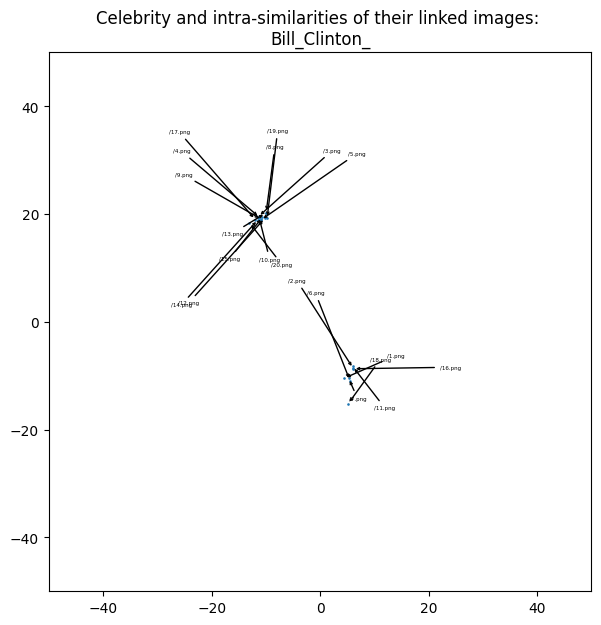

Number of embedded imgs -- 20
intra-sim/Vladimir_Putin_/1.png
intra-sim/Vladimir_Putin_/2.png
intra-sim/Vladimir_Putin_/3.png
intra-sim/Vladimir_Putin_/4.png
intra-sim/Vladimir_Putin_/5.png
intra-sim/Vladimir_Putin_/6.png
intra-sim/Vladimir_Putin_/7.png
intra-sim/Vladimir_Putin_/8.png
intra-sim/Vladimir_Putin_/9.png
intra-sim/Vladimir_Putin_/10.png
intra-sim/Vladimir_Putin_/11.png
intra-sim/Vladimir_Putin_/12.png
intra-sim/Vladimir_Putin_/13.png
intra-sim/Vladimir_Putin_/14.png
intra-sim/Vladimir_Putin_/15.png
intra-sim/Vladimir_Putin_/16.png
intra-sim/Vladimir_Putin_/17.png
intra-sim/Vladimir_Putin_/18.png
intra-sim/Vladimir_Putin_/19.png
intra-sim/Vladimir_Putin_/20.png


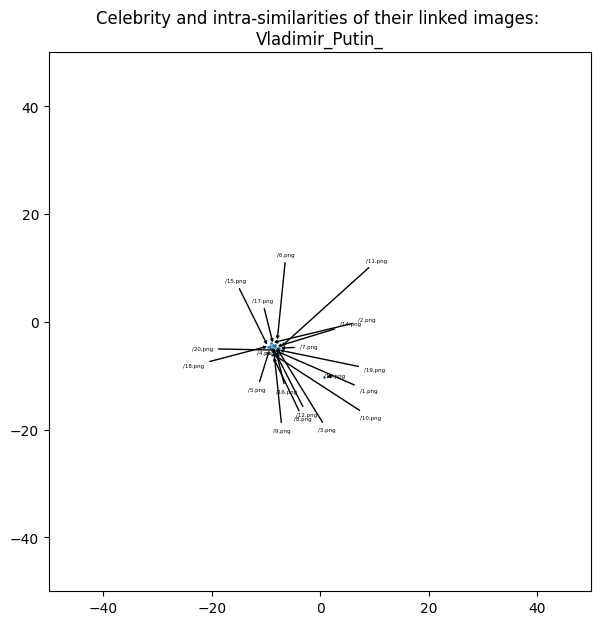

Number of embedded imgs -- 19
intra-sim/Luiz_Inacio_Lula_da_Silva_/1.png
intra-sim/Luiz_Inacio_Lula_da_Silva_/2.png
intra-sim/Luiz_Inacio_Lula_da_Silva_/3.png
intra-sim/Luiz_Inacio_Lula_da_Silva_/4.png
intra-sim/Luiz_Inacio_Lula_da_Silva_/5.png
intra-sim/Luiz_Inacio_Lula_da_Silva_/6.png
intra-sim/Luiz_Inacio_Lula_da_Silva_/7.png
intra-sim/Luiz_Inacio_Lula_da_Silva_/8.png
intra-sim/Luiz_Inacio_Lula_da_Silva_/9.png
intra-sim/Luiz_Inacio_Lula_da_Silva_/10.png
intra-sim/Luiz_Inacio_Lula_da_Silva_/11.png
intra-sim/Luiz_Inacio_Lula_da_Silva_/12.png
intra-sim/Luiz_Inacio_Lula_da_Silva_/13.png
intra-sim/Luiz_Inacio_Lula_da_Silva_/14.png
intra-sim/Luiz_Inacio_Lula_da_Silva_/15.png
intra-sim/Luiz_Inacio_Lula_da_Silva_/16.png
intra-sim/Luiz_Inacio_Lula_da_Silva_/17.png
intra-sim/Luiz_Inacio_Lula_da_Silva_/19.png
intra-sim/Luiz_Inacio_Lula_da_Silva_/20.png


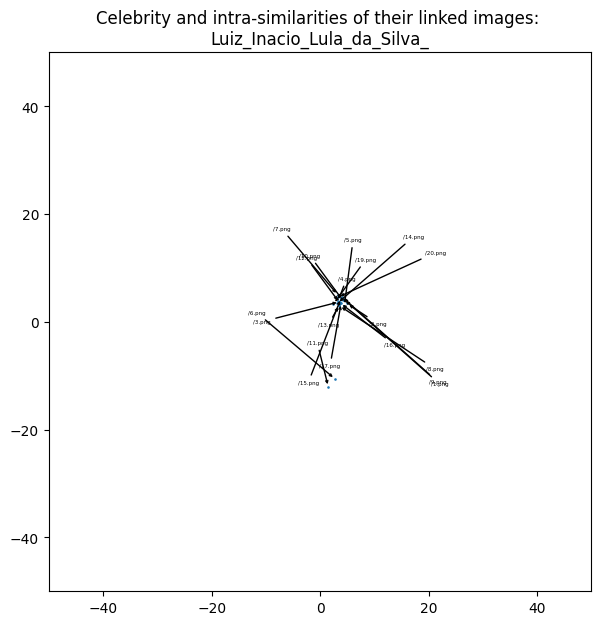

Number of embedded imgs -- 19
intra-sim/Ricardo_Lagos_/1.png
intra-sim/Ricardo_Lagos_/2.png
intra-sim/Ricardo_Lagos_/3.png
intra-sim/Ricardo_Lagos_/4.png
intra-sim/Ricardo_Lagos_/6.png
intra-sim/Ricardo_Lagos_/7.png
intra-sim/Ricardo_Lagos_/8.png
intra-sim/Ricardo_Lagos_/9.png
intra-sim/Ricardo_Lagos_/10.png
intra-sim/Ricardo_Lagos_/11.png
intra-sim/Ricardo_Lagos_/12.png
intra-sim/Ricardo_Lagos_/13.png
intra-sim/Ricardo_Lagos_/14.png
intra-sim/Ricardo_Lagos_/15.png
intra-sim/Ricardo_Lagos_/16.png
intra-sim/Ricardo_Lagos_/17.png
intra-sim/Ricardo_Lagos_/18.png
intra-sim/Ricardo_Lagos_/19.png
intra-sim/Ricardo_Lagos_/20.png


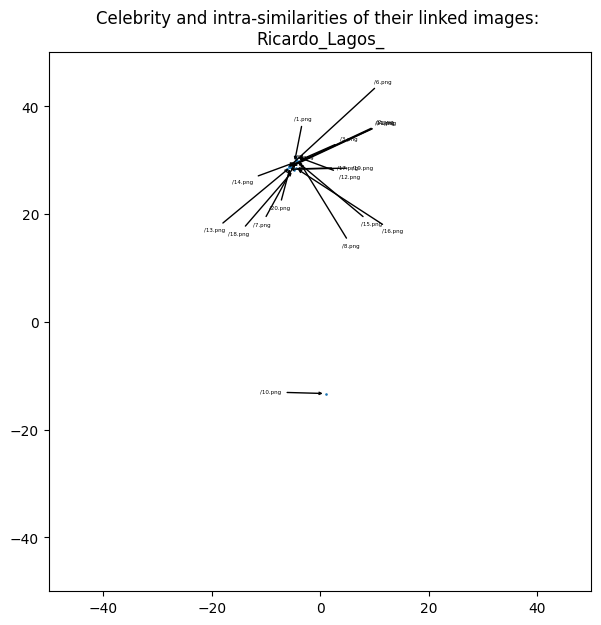

Number of embedded imgs -- 18
intra-sim/Angelina_Jolie_/1.png
intra-sim/Angelina_Jolie_/2.png
intra-sim/Angelina_Jolie_/3.png
intra-sim/Angelina_Jolie_/4.png
intra-sim/Angelina_Jolie_/5.png
intra-sim/Angelina_Jolie_/6.png
intra-sim/Angelina_Jolie_/8.png
intra-sim/Angelina_Jolie_/9.png
intra-sim/Angelina_Jolie_/10.png
intra-sim/Angelina_Jolie_/12.png
intra-sim/Angelina_Jolie_/13.png
intra-sim/Angelina_Jolie_/14.png
intra-sim/Angelina_Jolie_/15.png
intra-sim/Angelina_Jolie_/16.png
intra-sim/Angelina_Jolie_/17.png
intra-sim/Angelina_Jolie_/18.png
intra-sim/Angelina_Jolie_/19.png
intra-sim/Angelina_Jolie_/20.png


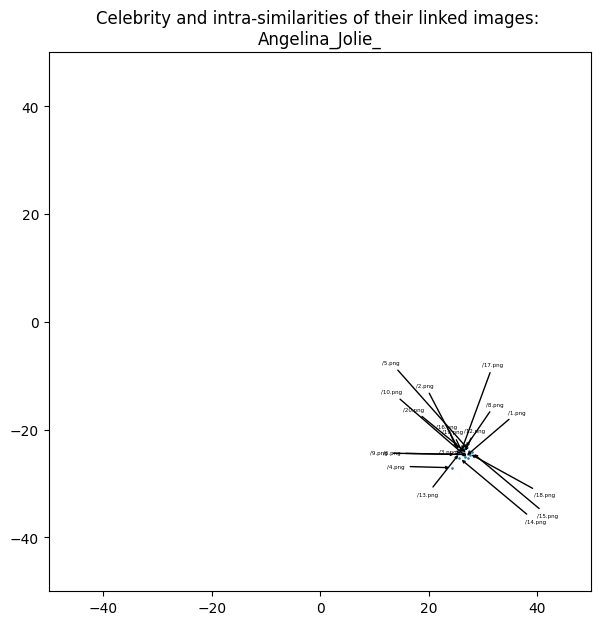

Number of embedded imgs -- 20
intra-sim/Gloria_Macapagal_Arroyo_/1.png
intra-sim/Gloria_Macapagal_Arroyo_/2.png
intra-sim/Gloria_Macapagal_Arroyo_/3.png
intra-sim/Gloria_Macapagal_Arroyo_/4.png
intra-sim/Gloria_Macapagal_Arroyo_/5.png
intra-sim/Gloria_Macapagal_Arroyo_/6.png
intra-sim/Gloria_Macapagal_Arroyo_/7.png
intra-sim/Gloria_Macapagal_Arroyo_/8.png
intra-sim/Gloria_Macapagal_Arroyo_/9.png
intra-sim/Gloria_Macapagal_Arroyo_/10.png
intra-sim/Gloria_Macapagal_Arroyo_/11.png
intra-sim/Gloria_Macapagal_Arroyo_/12.png
intra-sim/Gloria_Macapagal_Arroyo_/13.png
intra-sim/Gloria_Macapagal_Arroyo_/14.png
intra-sim/Gloria_Macapagal_Arroyo_/15.png
intra-sim/Gloria_Macapagal_Arroyo_/16.png
intra-sim/Gloria_Macapagal_Arroyo_/17.png
intra-sim/Gloria_Macapagal_Arroyo_/18.png
intra-sim/Gloria_Macapagal_Arroyo_/19.png
intra-sim/Gloria_Macapagal_Arroyo_/20.png


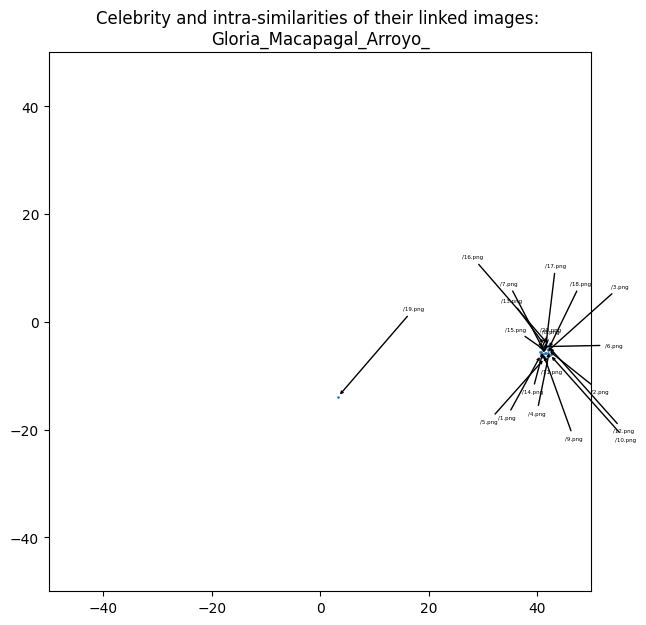

Number of embedded imgs -- 19
intra-sim/Megawati_Sukarnoputri_/1.png
intra-sim/Megawati_Sukarnoputri_/2.png
intra-sim/Megawati_Sukarnoputri_/3.png
intra-sim/Megawati_Sukarnoputri_/4.png
intra-sim/Megawati_Sukarnoputri_/5.png
intra-sim/Megawati_Sukarnoputri_/6.png
intra-sim/Megawati_Sukarnoputri_/7.png
intra-sim/Megawati_Sukarnoputri_/8.png
intra-sim/Megawati_Sukarnoputri_/9.png
intra-sim/Megawati_Sukarnoputri_/10.png
intra-sim/Megawati_Sukarnoputri_/11.png
intra-sim/Megawati_Sukarnoputri_/12.png
intra-sim/Megawati_Sukarnoputri_/13.png
intra-sim/Megawati_Sukarnoputri_/14.png
intra-sim/Megawati_Sukarnoputri_/16.png
intra-sim/Megawati_Sukarnoputri_/17.png
intra-sim/Megawati_Sukarnoputri_/18.png
intra-sim/Megawati_Sukarnoputri_/19.png
intra-sim/Megawati_Sukarnoputri_/20.png


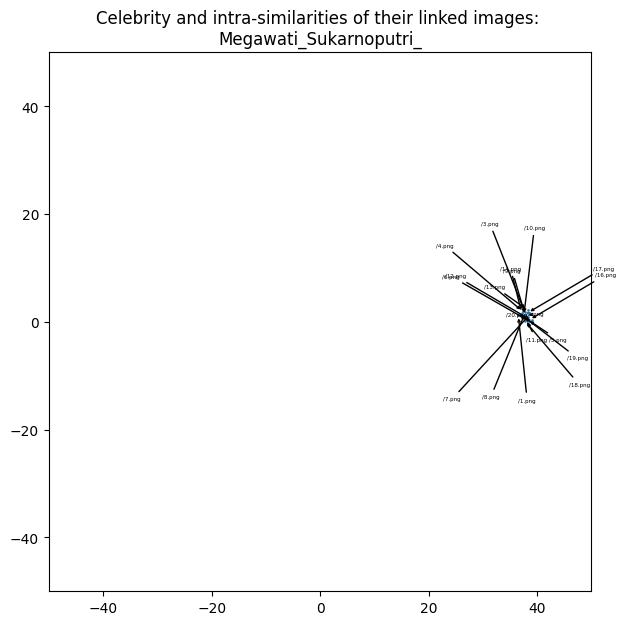

Number of embedded imgs -- 20
intra-sim/Winona_Ryder_/1.png
intra-sim/Winona_Ryder_/2.png
intra-sim/Winona_Ryder_/3.png
intra-sim/Winona_Ryder_/4.png
intra-sim/Winona_Ryder_/5.png
intra-sim/Winona_Ryder_/6.png
intra-sim/Winona_Ryder_/7.png
intra-sim/Winona_Ryder_/8.png
intra-sim/Winona_Ryder_/9.png
intra-sim/Winona_Ryder_/10.png
intra-sim/Winona_Ryder_/11.png
intra-sim/Winona_Ryder_/12.png
intra-sim/Winona_Ryder_/13.png
intra-sim/Winona_Ryder_/14.png
intra-sim/Winona_Ryder_/15.png
intra-sim/Winona_Ryder_/16.png
intra-sim/Winona_Ryder_/17.png
intra-sim/Winona_Ryder_/18.png
intra-sim/Winona_Ryder_/19.png
intra-sim/Winona_Ryder_/20.png


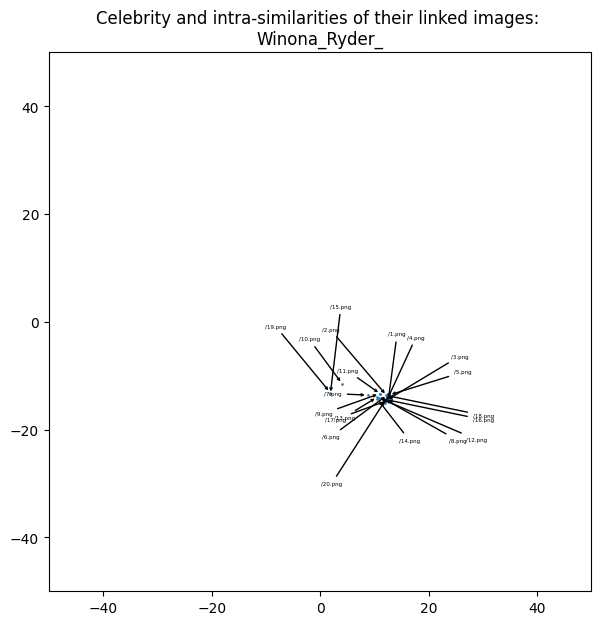

Number of embedded imgs -- 20
intra-sim/John_Ashcroft_/1.png
intra-sim/John_Ashcroft_/2.png
intra-sim/John_Ashcroft_/3.png
intra-sim/John_Ashcroft_/4.png
intra-sim/John_Ashcroft_/5.png
intra-sim/John_Ashcroft_/6.png
intra-sim/John_Ashcroft_/7.png
intra-sim/John_Ashcroft_/8.png
intra-sim/John_Ashcroft_/9.png
intra-sim/John_Ashcroft_/10.png
intra-sim/John_Ashcroft_/11.png
intra-sim/John_Ashcroft_/12.png
intra-sim/John_Ashcroft_/13.png
intra-sim/John_Ashcroft_/14.png
intra-sim/John_Ashcroft_/15.png
intra-sim/John_Ashcroft_/16.png
intra-sim/John_Ashcroft_/17.png
intra-sim/John_Ashcroft_/18.png
intra-sim/John_Ashcroft_/19.png
intra-sim/John_Ashcroft_/20.png


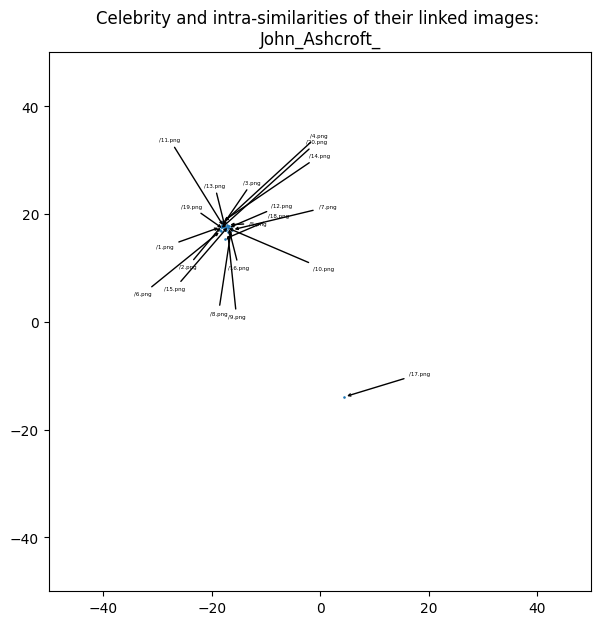

Number of embedded imgs -- 20
intra-sim/Gerhard_Schroeder_/1.png
intra-sim/Gerhard_Schroeder_/2.png
intra-sim/Gerhard_Schroeder_/3.png
intra-sim/Gerhard_Schroeder_/4.png
intra-sim/Gerhard_Schroeder_/5.png
intra-sim/Gerhard_Schroeder_/6.png
intra-sim/Gerhard_Schroeder_/7.png
intra-sim/Gerhard_Schroeder_/8.png
intra-sim/Gerhard_Schroeder_/9.png
intra-sim/Gerhard_Schroeder_/10.png
intra-sim/Gerhard_Schroeder_/11.png
intra-sim/Gerhard_Schroeder_/12.png
intra-sim/Gerhard_Schroeder_/13.png
intra-sim/Gerhard_Schroeder_/14.png
intra-sim/Gerhard_Schroeder_/15.png
intra-sim/Gerhard_Schroeder_/16.png
intra-sim/Gerhard_Schroeder_/17.png
intra-sim/Gerhard_Schroeder_/18.png
intra-sim/Gerhard_Schroeder_/19.png
intra-sim/Gerhard_Schroeder_/20.png


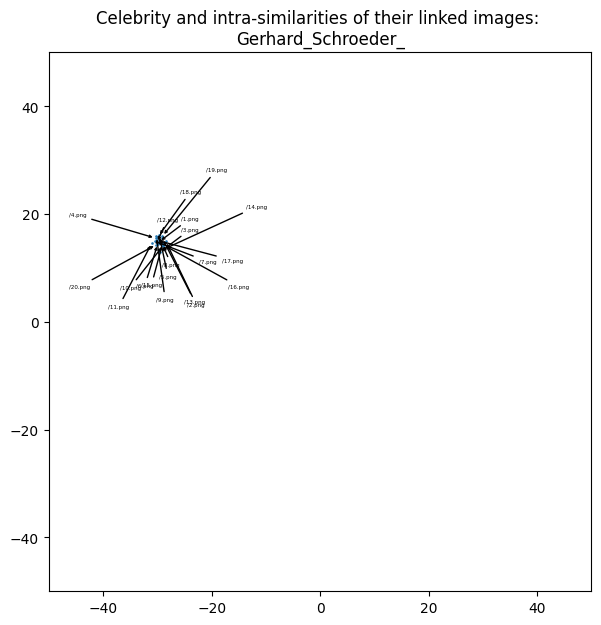

Number of embedded imgs -- 19
intra-sim/Laura_Bush_/1.png
intra-sim/Laura_Bush_/2.png
intra-sim/Laura_Bush_/3.png
intra-sim/Laura_Bush_/4.png
intra-sim/Laura_Bush_/5.png
intra-sim/Laura_Bush_/6.png
intra-sim/Laura_Bush_/7.png
intra-sim/Laura_Bush_/8.png
intra-sim/Laura_Bush_/9.png
intra-sim/Laura_Bush_/10.png
intra-sim/Laura_Bush_/11.png
intra-sim/Laura_Bush_/12.png
intra-sim/Laura_Bush_/13.png
intra-sim/Laura_Bush_/14.png
intra-sim/Laura_Bush_/15.png
intra-sim/Laura_Bush_/16.png
intra-sim/Laura_Bush_/17.png
intra-sim/Laura_Bush_/18.png
intra-sim/Laura_Bush_/20.png


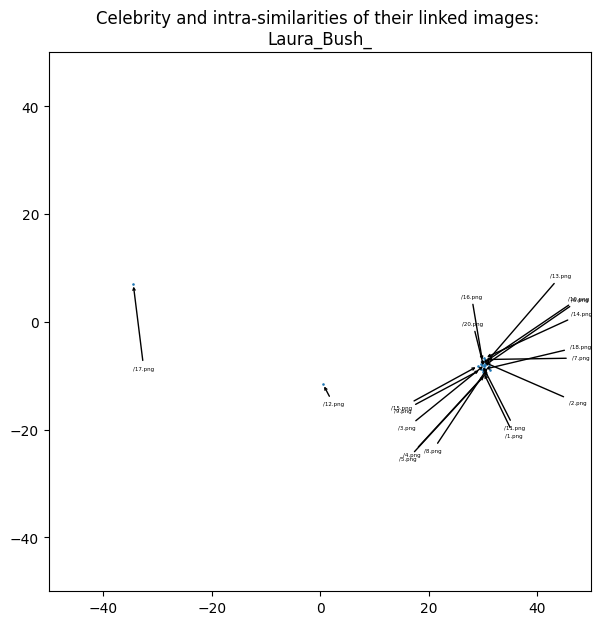

Number of embedded imgs -- 18
intra-sim/Hans_Blix_/1.png
intra-sim/Hans_Blix_/2.png
intra-sim/Hans_Blix_/3.png
intra-sim/Hans_Blix_/4.png
intra-sim/Hans_Blix_/5.png
intra-sim/Hans_Blix_/6.png
intra-sim/Hans_Blix_/7.png
intra-sim/Hans_Blix_/8.png
intra-sim/Hans_Blix_/9.png
intra-sim/Hans_Blix_/10.png
intra-sim/Hans_Blix_/11.png
intra-sim/Hans_Blix_/12.png
intra-sim/Hans_Blix_/13.png
intra-sim/Hans_Blix_/14.png
intra-sim/Hans_Blix_/15.png
intra-sim/Hans_Blix_/16.png
intra-sim/Hans_Blix_/17.png
intra-sim/Hans_Blix_/18.png


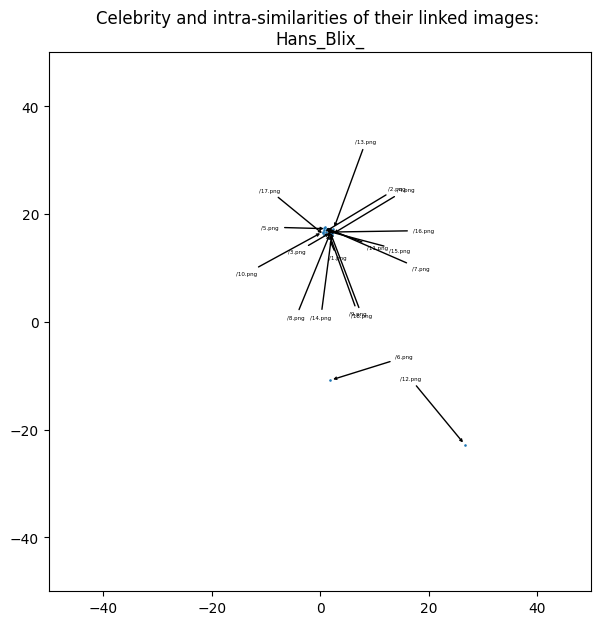

Number of embedded imgs -- 20
intra-sim/Juan_Carlos_Ferrero_/1.png
intra-sim/Juan_Carlos_Ferrero_/2.png
intra-sim/Juan_Carlos_Ferrero_/3.png
intra-sim/Juan_Carlos_Ferrero_/4.png
intra-sim/Juan_Carlos_Ferrero_/5.png
intra-sim/Juan_Carlos_Ferrero_/6.png
intra-sim/Juan_Carlos_Ferrero_/7.png
intra-sim/Juan_Carlos_Ferrero_/8.png
intra-sim/Juan_Carlos_Ferrero_/9.png
intra-sim/Juan_Carlos_Ferrero_/10.png
intra-sim/Juan_Carlos_Ferrero_/11.png
intra-sim/Juan_Carlos_Ferrero_/12.png
intra-sim/Juan_Carlos_Ferrero_/13.png
intra-sim/Juan_Carlos_Ferrero_/14.png
intra-sim/Juan_Carlos_Ferrero_/15.png
intra-sim/Juan_Carlos_Ferrero_/16.png
intra-sim/Juan_Carlos_Ferrero_/17.png
intra-sim/Juan_Carlos_Ferrero_/18.png
intra-sim/Juan_Carlos_Ferrero_/19.png
intra-sim/Juan_Carlos_Ferrero_/20.png


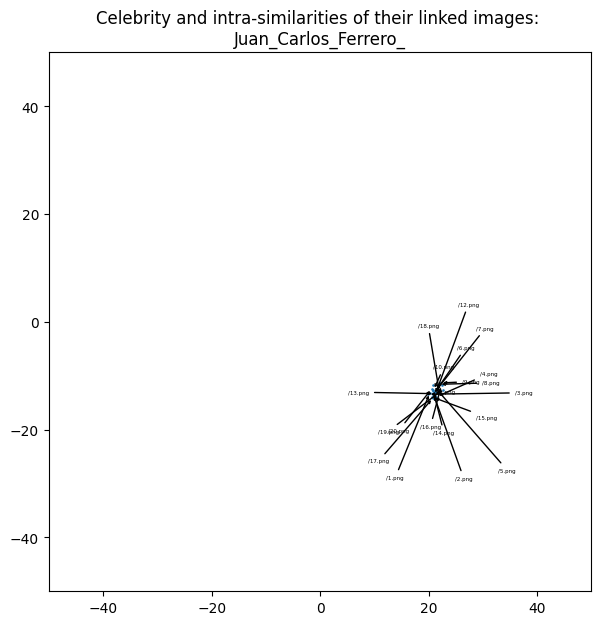

Number of embedded imgs -- 20
intra-sim/Jack_Straw_/1.png
intra-sim/Jack_Straw_/2.png
intra-sim/Jack_Straw_/3.png
intra-sim/Jack_Straw_/4.png
intra-sim/Jack_Straw_/5.png
intra-sim/Jack_Straw_/6.png
intra-sim/Jack_Straw_/7.png
intra-sim/Jack_Straw_/8.png
intra-sim/Jack_Straw_/9.png
intra-sim/Jack_Straw_/10.png
intra-sim/Jack_Straw_/11.png
intra-sim/Jack_Straw_/12.png
intra-sim/Jack_Straw_/13.png
intra-sim/Jack_Straw_/14.png
intra-sim/Jack_Straw_/15.png
intra-sim/Jack_Straw_/16.png
intra-sim/Jack_Straw_/17.png
intra-sim/Jack_Straw_/18.png
intra-sim/Jack_Straw_/19.png
intra-sim/Jack_Straw_/20.png


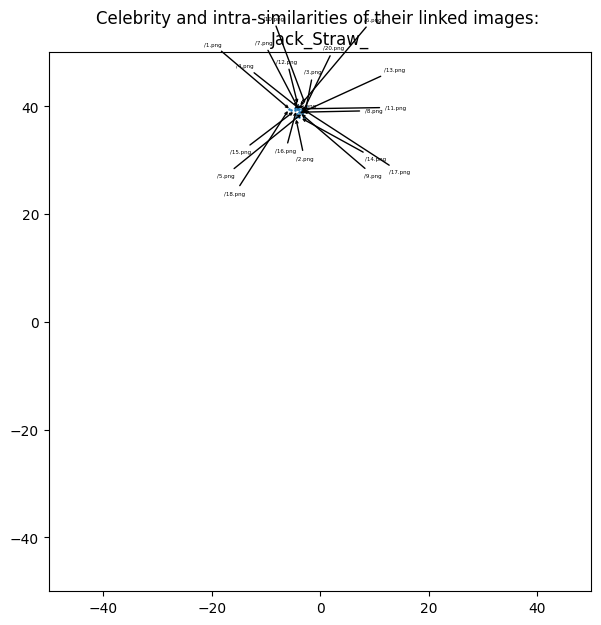

Number of embedded imgs -- 20
intra-sim/Alejandro_Toledo_/1.png
intra-sim/Alejandro_Toledo_/2.png
intra-sim/Alejandro_Toledo_/3.png
intra-sim/Alejandro_Toledo_/4.png
intra-sim/Alejandro_Toledo_/5.png
intra-sim/Alejandro_Toledo_/6.png
intra-sim/Alejandro_Toledo_/7.png
intra-sim/Alejandro_Toledo_/8.png
intra-sim/Alejandro_Toledo_/9.png
intra-sim/Alejandro_Toledo_/10.png
intra-sim/Alejandro_Toledo_/11.png
intra-sim/Alejandro_Toledo_/12.png
intra-sim/Alejandro_Toledo_/13.png
intra-sim/Alejandro_Toledo_/14.png
intra-sim/Alejandro_Toledo_/15.png
intra-sim/Alejandro_Toledo_/16.png
intra-sim/Alejandro_Toledo_/17.png
intra-sim/Alejandro_Toledo_/18.png
intra-sim/Alejandro_Toledo_/19.png
intra-sim/Alejandro_Toledo_/20.png


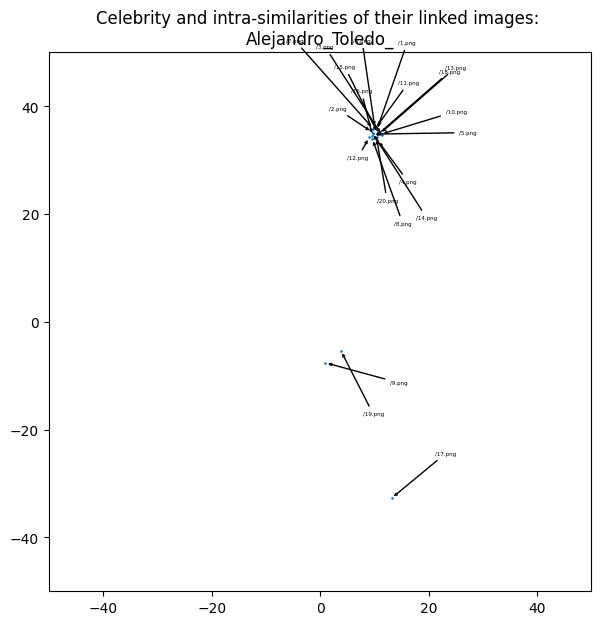

Number of embedded imgs -- 20
intra-sim/Tiger_Woods_/1.png
intra-sim/Tiger_Woods_/2.png
intra-sim/Tiger_Woods_/3.png
intra-sim/Tiger_Woods_/4.png
intra-sim/Tiger_Woods_/5.png
intra-sim/Tiger_Woods_/6.png
intra-sim/Tiger_Woods_/7.png
intra-sim/Tiger_Woods_/8.png
intra-sim/Tiger_Woods_/9.png
intra-sim/Tiger_Woods_/10.png
intra-sim/Tiger_Woods_/11.png
intra-sim/Tiger_Woods_/12.png
intra-sim/Tiger_Woods_/13.png
intra-sim/Tiger_Woods_/14.png
intra-sim/Tiger_Woods_/15.png
intra-sim/Tiger_Woods_/16.png
intra-sim/Tiger_Woods_/17.png
intra-sim/Tiger_Woods_/18.png
intra-sim/Tiger_Woods_/19.png
intra-sim/Tiger_Woods_/20.png


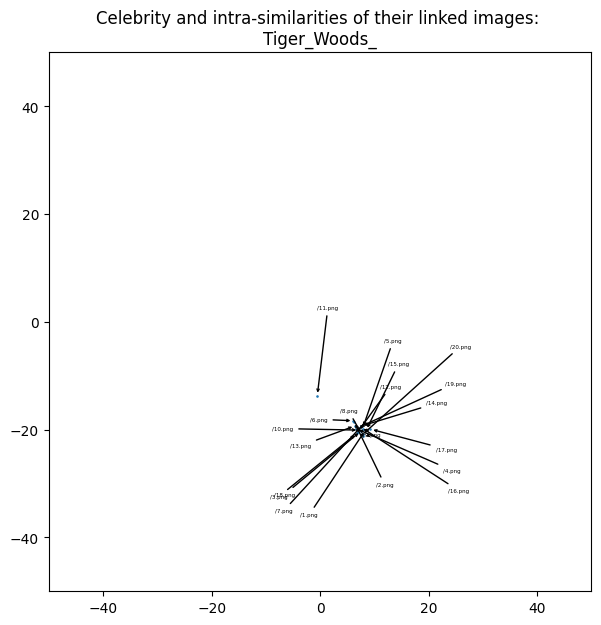

Number of embedded imgs -- 18
intra-sim/Jennifer_Capriati_/1.png
intra-sim/Jennifer_Capriati_/3.png
intra-sim/Jennifer_Capriati_/4.png
intra-sim/Jennifer_Capriati_/5.png
intra-sim/Jennifer_Capriati_/6.png
intra-sim/Jennifer_Capriati_/7.png
intra-sim/Jennifer_Capriati_/8.png
intra-sim/Jennifer_Capriati_/9.png
intra-sim/Jennifer_Capriati_/10.png
intra-sim/Jennifer_Capriati_/11.png
intra-sim/Jennifer_Capriati_/12.png
intra-sim/Jennifer_Capriati_/13.png
intra-sim/Jennifer_Capriati_/14.png
intra-sim/Jennifer_Capriati_/15.png
intra-sim/Jennifer_Capriati_/16.png
intra-sim/Jennifer_Capriati_/17.png
intra-sim/Jennifer_Capriati_/19.png
intra-sim/Jennifer_Capriati_/20.png


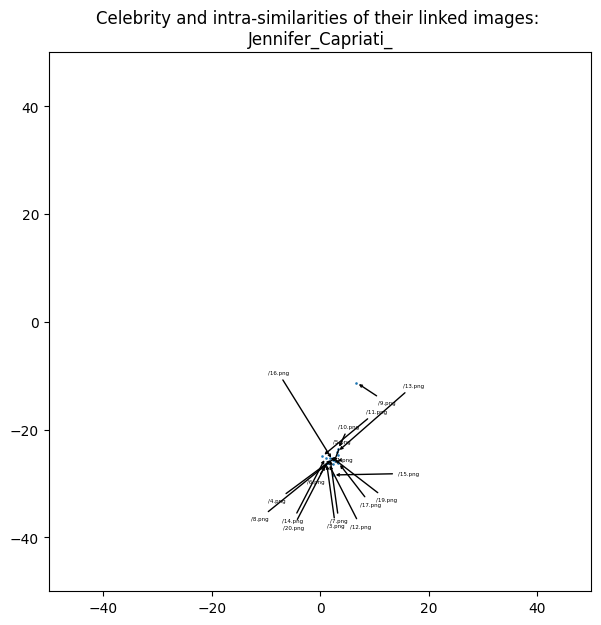

Number of embedded imgs -- 20
intra-sim/Hugo_Chavez_/1.png
intra-sim/Hugo_Chavez_/2.png
intra-sim/Hugo_Chavez_/3.png
intra-sim/Hugo_Chavez_/4.png
intra-sim/Hugo_Chavez_/5.png
intra-sim/Hugo_Chavez_/6.png
intra-sim/Hugo_Chavez_/7.png
intra-sim/Hugo_Chavez_/8.png
intra-sim/Hugo_Chavez_/9.png
intra-sim/Hugo_Chavez_/10.png
intra-sim/Hugo_Chavez_/11.png
intra-sim/Hugo_Chavez_/12.png
intra-sim/Hugo_Chavez_/13.png
intra-sim/Hugo_Chavez_/14.png
intra-sim/Hugo_Chavez_/15.png
intra-sim/Hugo_Chavez_/16.png
intra-sim/Hugo_Chavez_/17.png
intra-sim/Hugo_Chavez_/18.png
intra-sim/Hugo_Chavez_/19.png
intra-sim/Hugo_Chavez_/20.png


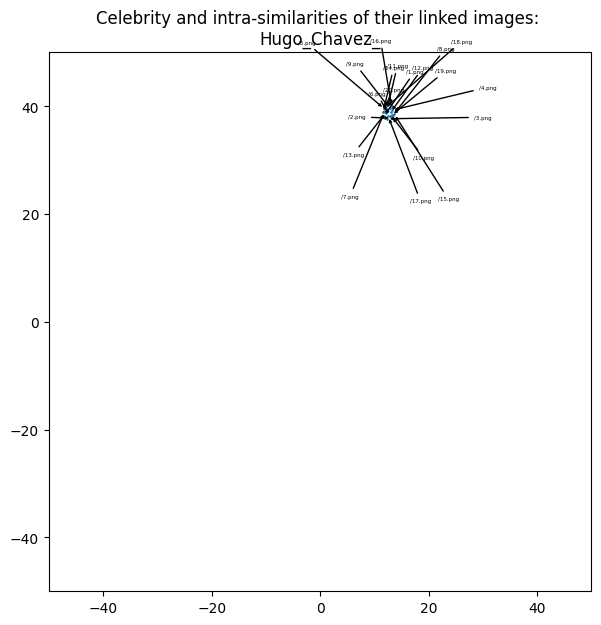

Number of embedded imgs -- 20
intra-sim/Vicente_Fox_/1.png
intra-sim/Vicente_Fox_/2.png
intra-sim/Vicente_Fox_/3.png
intra-sim/Vicente_Fox_/4.png
intra-sim/Vicente_Fox_/5.png
intra-sim/Vicente_Fox_/6.png
intra-sim/Vicente_Fox_/7.png
intra-sim/Vicente_Fox_/8.png
intra-sim/Vicente_Fox_/9.png
intra-sim/Vicente_Fox_/10.png
intra-sim/Vicente_Fox_/11.png
intra-sim/Vicente_Fox_/12.png
intra-sim/Vicente_Fox_/13.png
intra-sim/Vicente_Fox_/14.png
intra-sim/Vicente_Fox_/15.png
intra-sim/Vicente_Fox_/16.png
intra-sim/Vicente_Fox_/17.png
intra-sim/Vicente_Fox_/18.png
intra-sim/Vicente_Fox_/19.png
intra-sim/Vicente_Fox_/20.png


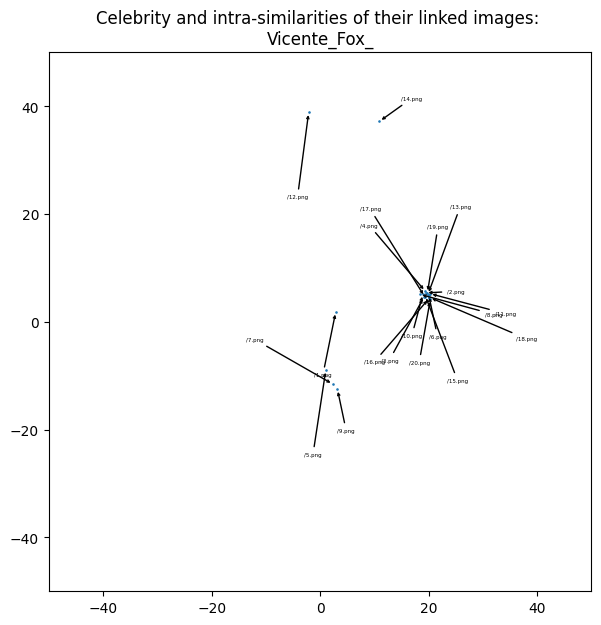

Number of embedded imgs -- 20
intra-sim/George_W_Bush_/1.png
intra-sim/George_W_Bush_/2.png
intra-sim/George_W_Bush_/3.png
intra-sim/George_W_Bush_/4.png
intra-sim/George_W_Bush_/5.png
intra-sim/George_W_Bush_/6.png
intra-sim/George_W_Bush_/7.png
intra-sim/George_W_Bush_/8.png
intra-sim/George_W_Bush_/9.png
intra-sim/George_W_Bush_/10.png
intra-sim/George_W_Bush_/11.png
intra-sim/George_W_Bush_/12.png
intra-sim/George_W_Bush_/13.png
intra-sim/George_W_Bush_/14.png
intra-sim/George_W_Bush_/15.png
intra-sim/George_W_Bush_/16.png
intra-sim/George_W_Bush_/17.png
intra-sim/George_W_Bush_/18.png
intra-sim/George_W_Bush_/19.png
intra-sim/George_W_Bush_/20.png


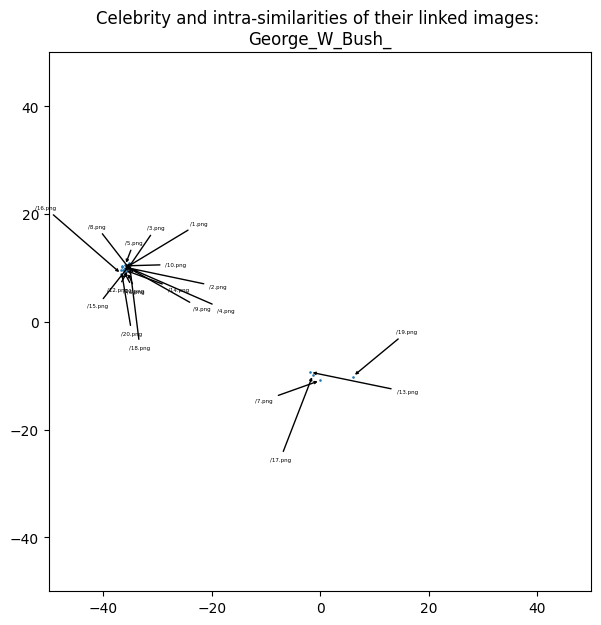

Number of embedded imgs -- 20
intra-sim/Jeremy_Greenstock_/1.png
intra-sim/Jeremy_Greenstock_/2.png
intra-sim/Jeremy_Greenstock_/3.png
intra-sim/Jeremy_Greenstock_/4.png
intra-sim/Jeremy_Greenstock_/5.png
intra-sim/Jeremy_Greenstock_/6.png
intra-sim/Jeremy_Greenstock_/7.png
intra-sim/Jeremy_Greenstock_/8.png
intra-sim/Jeremy_Greenstock_/9.png
intra-sim/Jeremy_Greenstock_/10.png
intra-sim/Jeremy_Greenstock_/11.png
intra-sim/Jeremy_Greenstock_/12.png
intra-sim/Jeremy_Greenstock_/13.png
intra-sim/Jeremy_Greenstock_/14.png
intra-sim/Jeremy_Greenstock_/15.png
intra-sim/Jeremy_Greenstock_/16.png
intra-sim/Jeremy_Greenstock_/17.png
intra-sim/Jeremy_Greenstock_/18.png
intra-sim/Jeremy_Greenstock_/19.png
intra-sim/Jeremy_Greenstock_/20.png


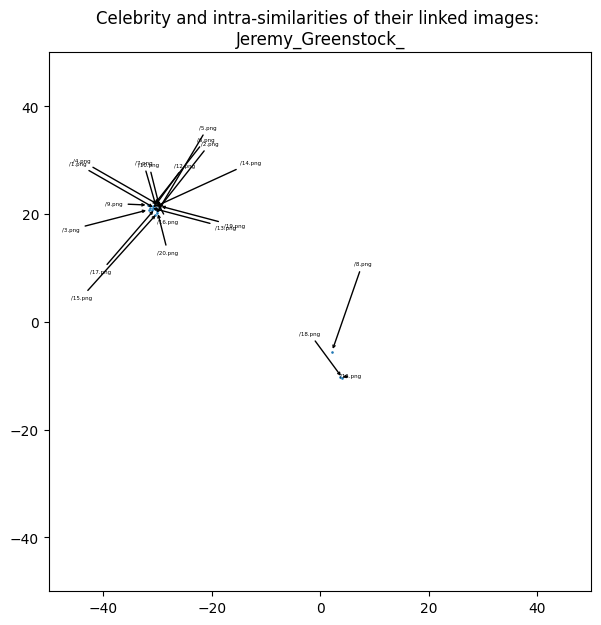

Number of embedded imgs -- 20
intra-sim/Saddam_Hussein_/1.png
intra-sim/Saddam_Hussein_/2.png
intra-sim/Saddam_Hussein_/3.png
intra-sim/Saddam_Hussein_/4.png
intra-sim/Saddam_Hussein_/5.png
intra-sim/Saddam_Hussein_/6.png
intra-sim/Saddam_Hussein_/7.png
intra-sim/Saddam_Hussein_/8.png
intra-sim/Saddam_Hussein_/9.png
intra-sim/Saddam_Hussein_/10.png
intra-sim/Saddam_Hussein_/11.png
intra-sim/Saddam_Hussein_/12.png
intra-sim/Saddam_Hussein_/13.png
intra-sim/Saddam_Hussein_/14.png
intra-sim/Saddam_Hussein_/15.png
intra-sim/Saddam_Hussein_/16.png
intra-sim/Saddam_Hussein_/17.png
intra-sim/Saddam_Hussein_/18.png
intra-sim/Saddam_Hussein_/19.png
intra-sim/Saddam_Hussein_/20.png


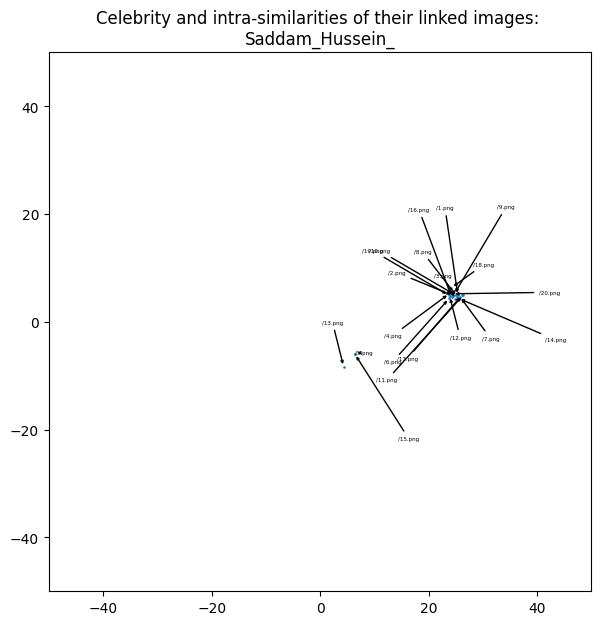

Number of embedded imgs -- 20
intra-sim/Donald_Rumsfeld_/1.png
intra-sim/Donald_Rumsfeld_/2.png
intra-sim/Donald_Rumsfeld_/3.png
intra-sim/Donald_Rumsfeld_/4.png
intra-sim/Donald_Rumsfeld_/5.png
intra-sim/Donald_Rumsfeld_/6.png
intra-sim/Donald_Rumsfeld_/7.png
intra-sim/Donald_Rumsfeld_/8.png
intra-sim/Donald_Rumsfeld_/9.png
intra-sim/Donald_Rumsfeld_/10.png
intra-sim/Donald_Rumsfeld_/11.png
intra-sim/Donald_Rumsfeld_/12.png
intra-sim/Donald_Rumsfeld_/13.png
intra-sim/Donald_Rumsfeld_/14.png
intra-sim/Donald_Rumsfeld_/15.png
intra-sim/Donald_Rumsfeld_/16.png
intra-sim/Donald_Rumsfeld_/17.png
intra-sim/Donald_Rumsfeld_/18.png
intra-sim/Donald_Rumsfeld_/19.png
intra-sim/Donald_Rumsfeld_/20.png


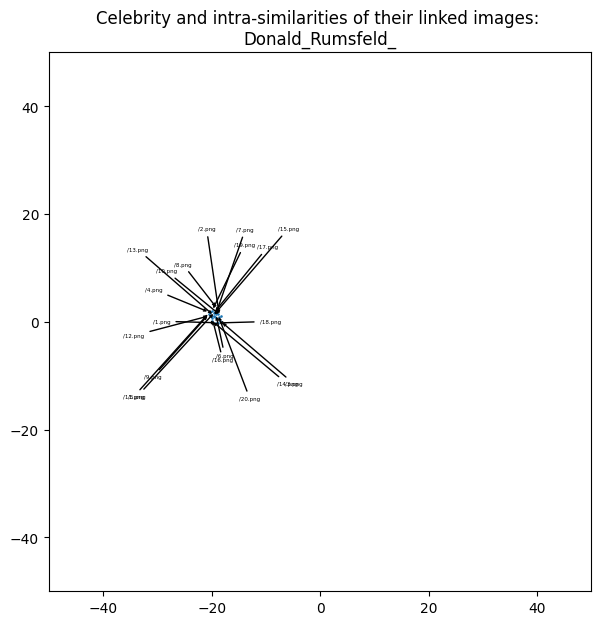

Number of embedded imgs -- 19
intra-sim/Jacques_Chirac_/1.png
intra-sim/Jacques_Chirac_/2.png
intra-sim/Jacques_Chirac_/4.png
intra-sim/Jacques_Chirac_/5.png
intra-sim/Jacques_Chirac_/6.png
intra-sim/Jacques_Chirac_/7.png
intra-sim/Jacques_Chirac_/8.png
intra-sim/Jacques_Chirac_/9.png
intra-sim/Jacques_Chirac_/10.png
intra-sim/Jacques_Chirac_/11.png
intra-sim/Jacques_Chirac_/12.png
intra-sim/Jacques_Chirac_/13.png
intra-sim/Jacques_Chirac_/14.png
intra-sim/Jacques_Chirac_/15.png
intra-sim/Jacques_Chirac_/16.png
intra-sim/Jacques_Chirac_/17.png
intra-sim/Jacques_Chirac_/18.png
intra-sim/Jacques_Chirac_/19.png
intra-sim/Jacques_Chirac_/20.png


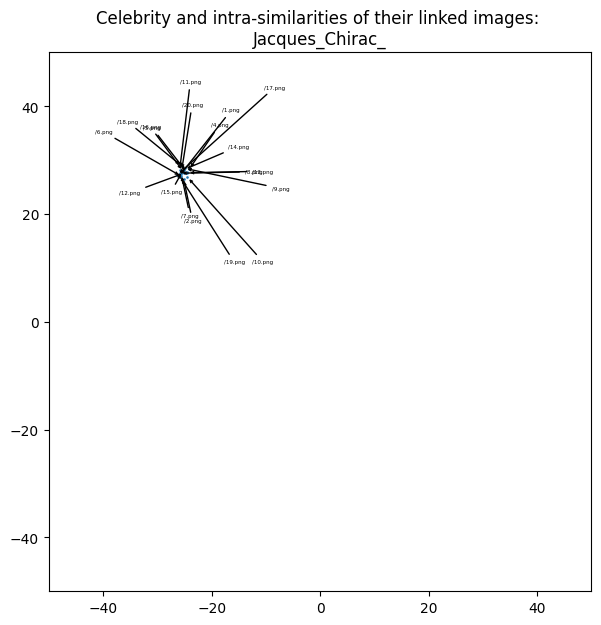

Number of embedded imgs -- 20
intra-sim/Nestor_Kirchner_/1.png
intra-sim/Nestor_Kirchner_/2.png
intra-sim/Nestor_Kirchner_/3.png
intra-sim/Nestor_Kirchner_/4.png
intra-sim/Nestor_Kirchner_/5.png
intra-sim/Nestor_Kirchner_/6.png
intra-sim/Nestor_Kirchner_/7.png
intra-sim/Nestor_Kirchner_/8.png
intra-sim/Nestor_Kirchner_/9.png
intra-sim/Nestor_Kirchner_/10.png
intra-sim/Nestor_Kirchner_/11.png
intra-sim/Nestor_Kirchner_/12.png
intra-sim/Nestor_Kirchner_/13.png
intra-sim/Nestor_Kirchner_/14.png
intra-sim/Nestor_Kirchner_/15.png
intra-sim/Nestor_Kirchner_/16.png
intra-sim/Nestor_Kirchner_/17.png
intra-sim/Nestor_Kirchner_/18.png
intra-sim/Nestor_Kirchner_/19.png
intra-sim/Nestor_Kirchner_/20.png


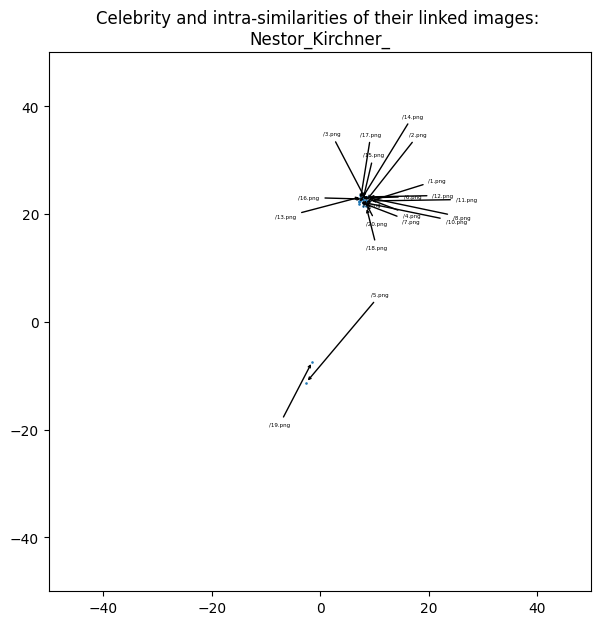

In [95]:
# T-SNE arrays are aggregated together to fit for the whole collection of embeddings across all people

import random

# Approximated to 2D
tsne = TSNE(n_components=2, learning_rate='auto', init='random').fit_transform(np.array(pure_embeddings))

# still preserve the ID of each image
i = 0
for person in X.keys():
  for impath in X[person].keys():
    X[person][impath]['tsne'] = tsne[i]
    i += 1

for person in X.keys():
  points = []
  for impath in X[person].keys():
    points.append({
        impath: X[person][impath]['tsne']
    })

  labels = [list(objct.keys())[0] for objct in points]

  points = np.array([objct[list(objct.keys())[0]] for objct in points])
  print("Number of embedded imgs --", len(points))
  fig, ax = plt.subplots(figsize=(7, 7))
  ax.set_xlim([-50, 50])
  ax.set_ylim([-50, 50])
  ax.scatter(points[:,0], points[:,1], marker ='.', s=3)
  for i, txt in enumerate(labels):
      print(txt)
      ax.annotate(txt.replace(f'intra-sim/{person}', ''), (points[:,0][i], points[:,1][i]), xytext=(points[:,0][i]+random.choice(range(-16,17,4)), points[:,1][i]+random.choice(range(-16,17,4))), fontsize=4, arrowprops=dict(arrowstyle='->'))
  plt.title(f"Celebrity and intra-similarities of their linked images: \n{person}")
  plt.savefig(f'{person}_embeddings_tsne.png', dpi=300)
  plt.show()

In [ ]:
! mkdir plots
! mv *.png plots/
! zip -r tsne-embeddings_per-person-plots.zip plots

In [107]:
### SAVE PROGRESS AS .pickle (can also be converted to CSV)
with open('tsne_embeddings_per_person_image.pickle', 'wb') as file_:
    pickle.dump(X, file_, protocol=pickle.HIGHEST_PROTOCOL)

----

## **Race, Gender Labelling**

In [ ]:
results = {}
not_recog = []

for detector in ['dlib', 'mtcnn', 'retinaface']:
  for person in glob.glob(f'intra-sim/*'):
    for image in glob.glob(f'{person}/*.png'): # person has the "intra-sim/" prefix already hence not needed
      try:
        objs = DeepFace.analyze(
            img_path=image,
            detector_backend=detector,
            actions=['race', 'gender']
        )
        print(objs)
        results[f'{detector}/{image.replace("intra-sim/", "").replace("/","-")}'] = objs
      except Exception as e:
        print(f"error with image >>", image, e) # here, detection phase was unsuccessful
        not_recog.append(image)

### SAVE PROGRESS AS .pickle (can also be converted to CSV)
with open('lfw-labels.pickle', 'wb') as file_:
    pickle.dump(results, file_, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
len(results)

In [ ]:
not_recog